In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import numpy as np
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/気合のCOVID19"

PATIENT_CSV = os.path.join(
    BASE_DIR,
    "00_共通・研究管理",
    "02_データ定義・元データ",
    "患者データファイル.csv"
)

SPLIT_CSV = os.path.join(
    BASE_DIR,
    "00_共通・研究管理",
    "03_患者選定",
    "COVID19_固定患者split_1277.csv"
)

patient_df = pd.read_csv(PATIENT_CSV)
split_df = pd.read_csv(SPLIT_CSV)

print("Patient data:", patient_df.shape)
print("Split data  :", split_df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Patient data: (1384, 131)
Split data  : (1277, 5)


In [ ]:
print(split_df.columns.tolist())
display(split_df.head())

['Subject ID', 'to_patient_id', 'last.status', 'true_label', 'split']


,Subject ID,to_patient_id,last.status,true_label,split
0,A934023,A934023,discharged,0,train
1,A333626,A333626,discharged,0,train
2,A363365,A363365,discharged,0,train
3,A303446,A303446,discharged,0,train
4,A463459,A463459,discharged,0,train


In [ ]:
clinical_df = patient_df.merge(
    split_df[
        ["Subject ID", "true_label", "split"]
    ],
    left_on="to_patient_id",
    right_on="Subject ID",
    how="inner",
    validate="one_to_one"
)

print("Fixed cohort:", len(clinical_df))

print("\nSplit counts:")
print(clinical_df["split"].value_counts())

print("\nOutcome by split:")
print(
    pd.crosstab(
        clinical_df["split"],
        clinical_df["true_label"]
    )
)

Fixed cohort: 1277

Split counts:
split
train    1021
test      128
val       128
Name: count, dtype: int64

Outcome by split:
true_label    0    1
split               
test        111   17
train       886  135
val         111   17


In [ ]:
train_df = clinical_df[
    clinical_df["split"] == "train"
].copy()

print("Train n:", len(train_df))
print("Train deaths:", int(train_df["true_label"].sum()))
print("Train survivors:", int((train_df["true_label"] == 0).sum()))

Train n: 1021
Train deaths: 135
Train survivors: 886


In [ ]:
audit_rows = []

original_columns = patient_df.columns.tolist()

for col in original_columns:
    s = train_df[col]

    n_missing = int(s.isna().sum())
    missing_rate = n_missing / len(train_df)
    n_unique = int(s.nunique(dropna=True))

    unique_values = s.dropna().unique()

    if len(unique_values) > 10:
        examples = unique_values[:10].tolist()
    else:
        examples = unique_values.tolist()

    audit_rows.append({
        "variable": col,
        "dtype": str(s.dtype),
        "n_missing_train": n_missing,
        "missing_rate_train": missing_rate,
        "n_unique_train": n_unique,
        "example_values": str(examples)
    })

audit_df = pd.DataFrame(audit_rows)

audit_df = audit_df.sort_values(
    ["missing_rate_train", "variable"],
    ascending=[False, True]
).reset_index(drop=True)

print("Variables audited:", len(audit_df))
display(audit_df)

Variables audited: 131


,variable,dtype,n_missing_train,missing_rate_train,n_unique_train,example_values
0,kidney_transplant,object,1006,0.985309,1,['Yes']
1,kidney_replacement_therapy,object,978,0.957884,1,['Yes']
2,Proteinuria.above80,object,864,0.846229,2,"[True, False]"
3,invasive_vent_days,float64,864,0.846229,37,"[28.0, 23.0, 13.0, 6.0, 8.0, 9.0, 40.0, 7.0, 4..."
4,33254-4_pH of Arterial blood adjusted to patie...,float64,852,0.834476,45,"[7.45, 7.42, 7.46, 7.29, 7.38, 7.4, 7.32, 7.41..."
...,...,...,...,...,...,...
126,length_of_stay,int64,0,0.000000,58,"[9, 28, 3, 8, 1, 11, 6, 14, 10, 5]"
127,to_patient_id,object,0,0.000000,1021,"['A917122', 'A968238', 'A300871', 'A205701', '..."
128,visit_concept_name,object,0,0.000000,2,"['Inpatient Visit', 'Emergency Room Visit']"
129,visit_start_datetime,object,0,0.000000,26,"['1/1/1901', '1/5/1901', '1/8/1901', '12/23/19..."


In [ ]:
# ============================================
# Save Task B initial clinical-variable audit
# ============================================

SAVE_DIR = os.path.join(
    BASE_DIR,
    "02_TaskB_臨床データ",
    "01_変数選定"
)

os.makedirs(SAVE_DIR, exist_ok=True)

AUDIT_CSV = os.path.join(
    SAVE_DIR,
    "TaskB_臨床変数131項目_Train再監査.csv"
)

audit_df.to_csv(
    AUDIT_CSV,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:")
print(AUDIT_CSV)

print("\nShape:", audit_df.shape)

Saved:
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/01_変数選定/TaskB_臨床変数131項目_Train再監査.csv

Shape: (131, 6)


In [ ]:
high_missing_df = audit_df[
    audit_df["missing_rate_train"] >= 0.50
].copy()

print("Variables with >=50% missingness:", len(high_missing_df))

display(
    high_missing_df[
        [
            "variable",
            "n_missing_train",
            "missing_rate_train",
            "n_unique_train",
            "example_values"
        ]
    ]
)

Variables with >=50% missingness: 23


,variable,n_missing_train,missing_rate_train,n_unique_train,example_values
0,kidney_transplant,1006,0.985309,1,['Yes']
1,kidney_replacement_therapy,978,0.957884,1,['Yes']
2,Proteinuria.above80,864,0.846229,2,"[True, False]"
3,invasive_vent_days,864,0.846229,37,"[28.0, 23.0, 13.0, 6.0, 8.0, 9.0, 40.0, 7.0, 4..."
4,33254-4_pH of Arterial blood adjusted to patie...,852,0.834476,45,"[7.45, 7.42, 7.46, 7.29, 7.38, 7.4, 7.32, 7.41..."
5,blood_pH.above7.45,852,0.834476,2,"[False, True]"
6,blood_pH.below7.35,852,0.834476,2,"[False, True]"
7,blood_pH.between7.35and7.45,852,0.834476,2,"[True, False]"
8,13457-7_Cholesterol in LDL [Mass/volume] in Se...,797,0.780607,93,"[72.0, 73.0, 31.0, 138.0, 117.0, 122.0, 32.0, ..."
9,13458-5_Cholesterol in VLDL [Mass/volume] in S...,796,0.779628,46,"[17.0, 16.0, 23.0, 20.0, 30.0, 21.0, 31.0, 28...."


In [ ]:
print(train_df["kidney_transplant"].value_counts(dropna=False))
print()
print(train_df["kidney_replacement_therapy"].value_counts(dropna=False))

kidney_transplant
NaN    1006
Yes      15
Name: count, dtype: int64

kidney_replacement_therapy
NaN    978
Yes     43
Name: count, dtype: int64


In [ ]:
# ============================================
# Step 1: classify variables with >=50% missingness
# ============================================

audit_work = audit_df.copy()

audit_work["decision"] = ""
audit_work["reason"] = ""

high_missing_mask = audit_work["missing_rate_train"] >= 0.50

# 原則：Train欠測率50%以上は除外
audit_work.loc[high_missing_mask, "decision"] = "Exclude"
audit_work.loc[high_missing_mask, "reason"] = \
    "Train missingness >=50%"

# T0後情報：欠測率とは別に情報リークとして除外
post_admission_vars = [
    "kidney_replacement_therapy",
    "invasive_vent_days"
]

audit_work.loc[
    audit_work["variable"].isin(post_admission_vars),
    "decision"
] = "Exclude"

audit_work.loc[
    audit_work["variable"].isin(post_admission_vars),
    "reason"
] = "Post-admission information / outcome leakage"

# kidney_transplant は構造的欠測の可能性があるため保留
audit_work.loc[
    audit_work["variable"] == "kidney_transplant",
    "decision"
] = "Review"

audit_work.loc[
    audit_work["variable"] == "kidney_transplant",
    "reason"
] = "Possible structural missingness (Yes recorded, NaN otherwise); definition must be confirmed"

high_missing_review = audit_work[
    audit_work["missing_rate_train"] >= 0.50
][
    [
        "variable",
        "n_missing_train",
        "missing_rate_train",
        "decision",
        "reason"
    ]
]

display(high_missing_review)

print("\nDecision counts:")
print(high_missing_review["decision"].value_counts())

,variable,n_missing_train,missing_rate_train,decision,reason
0,kidney_transplant,1006,0.985309,Review,"Possible structural missingness (Yes recorded,..."
1,kidney_replacement_therapy,978,0.957884,Exclude,Post-admission information / outcome leakage
2,Proteinuria.above80,864,0.846229,Exclude,Train missingness >=50%
3,invasive_vent_days,864,0.846229,Exclude,Post-admission information / outcome leakage
4,33254-4_pH of Arterial blood adjusted to patie...,852,0.834476,Exclude,Train missingness >=50%
5,blood_pH.above7.45,852,0.834476,Exclude,Train missingness >=50%
6,blood_pH.below7.35,852,0.834476,Exclude,Train missingness >=50%
7,blood_pH.between7.35and7.45,852,0.834476,Exclude,Train missingness >=50%
8,13457-7_Cholesterol in LDL [Mass/volume] in Se...,797,0.780607,Exclude,Train missingness >=50%
9,13458-5_Cholesterol in VLDL [Mass/volume] in S...,796,0.779628,Exclude,Train missingness >=50%



Decision counts:
decision
Exclude    22
Review      1
Name: count, dtype: int64


In [ ]:
post_admission_vars = [
    "is_icu",
    "was_ventilated",
    "invasive_vent_days",
    "length_of_stay",
    "Acute.Hepatic.Injury..during.hospitalization.",
    "Acute.Kidney.Injury..during.hospitalization.",
    "kidney_replacement_therapy",
    "therapeutic.exnox.Boolean",
    "therapeutic.heparin.Boolean",
    "anticoagulation.therapy"
]

In [ ]:
check_vars = post_admission_vars + ["last.status"]

for var in check_vars:
    print(var, "->", var in patient_df.columns)

is_icu -> True
was_ventilated -> True
invasive_vent_days -> True
length_of_stay -> True
Acute.Hepatic.Injury..during.hospitalization. -> True
Acute.Kidney.Injury..during.hospitalization. -> True
kidney_replacement_therapy -> True
therapeutic.exnox.Boolean -> True
therapeutic.heparin.Boolean -> True
anticoagulation.therapy -> False
last.status -> True


In [ ]:
[col for col in patient_df.columns if "antico" in col.lower()]

['Other.anticoagulation.therapy']

In [ ]:
post_admission_vars = [
    "is_icu",
    "was_ventilated",
    "invasive_vent_days",
    "length_of_stay",
    "Acute.Hepatic.Injury..during.hospitalization.",
    "Acute.Kidney.Injury..during.hospitalization.",
    "kidney_replacement_therapy",
    "therapeutic.exnox.Boolean",
    "therapeutic.heparin.Boolean",
    "Other.anticoagulation.therapy"
]

In [ ]:
# ============================================
# Step 3: post-admission / outcome leakage exclusions
# ============================================

post_admission_vars = [
    "is_icu",
    "was_ventilated",
    "invasive_vent_days",
    "length_of_stay",
    "Acute.Hepatic.Injury..during.hospitalization.",
    "Acute.Kidney.Injury..during.hospitalization.",
    "kidney_replacement_therapy",
    "therapeutic.exnox.Boolean",
    "therapeutic.heparin.Boolean",
    "Other.anticoagulation.therapy"
]

# 入院後情報
mask_post = audit_work["variable"].isin(post_admission_vars)

audit_work.loc[mask_post, "decision"] = "Exclude"
audit_work.loc[mask_post, "reason"] = \
    "Post-admission information / treatment; not available at admission T0"

# 直接のoutcome leakage
mask_outcome = audit_work["variable"] == "last.status"

audit_work.loc[mask_outcome, "decision"] = "Exclude"
audit_work.loc[mask_outcome, "reason"] = \
    "Outcome variable / direct outcome leakage"

display(
    audit_work[
        audit_work["variable"].isin(post_admission_vars + ["last.status"])
    ][
        ["variable", "missing_rate_train", "decision", "reason"]
    ]
)

,variable,missing_rate_train,decision,reason
1,kidney_replacement_therapy,0.957884,Exclude,Post-admission information / treatment; not av...
3,invasive_vent_days,0.846229,Exclude,Post-admission information / treatment; not av...
73,Acute.Hepatic.Injury..during.hospitalization.,0.173359,Exclude,Post-admission information / treatment; not av...
105,Other.anticoagulation.therapy,0.060725,Exclude,Post-admission information / treatment; not av...
106,therapeutic.exnox.Boolean,0.060725,Exclude,Post-admission information / treatment; not av...
107,therapeutic.heparin.Boolean,0.060725,Exclude,Post-admission information / treatment; not av...
121,Acute.Kidney.Injury..during.hospitalization.,0.000000,Exclude,Post-admission information / treatment; not av...
124,is_icu,0.000000,Exclude,Post-admission information / treatment; not av...
125,last.status,0.000000,Exclude,Outcome variable / direct outcome leakage
126,length_of_stay,0.000000,Exclude,Post-admission information / treatment; not av...


In [ ]:
old_threshold_duplicates = [
    # 血圧
    "SBP.below120",
    "DBP.below80",

    # 電解質
    "Potassium.above5.2",
    "Potassium.below3.5",

    # 炎症・凝固
    "D_dimer.above3000",
    "procalcitonin.above0.5",

    # 血糖・HbA1c
    "A1C.6.6to7.9",
    "A1C.8to9.9",
    "A1C.over10",
    "A1C.over6.5",
    "A1C.under6.5",

    # 血液pH
    "blood_pH.above7.45",
    "blood_pH.below7.35",
    "blood_pH.between7.35and7.45",

    # 尿所見など
    "Proteinuria.above80",
    "Microscopic_hematuria.above2",

    # ESR
    "ESR.above30"
]

old_threshold_check = pd.DataFrame({
    "variable": old_threshold_duplicates,
    "exists_now": [
        v in patient_df.columns
        for v in old_threshold_duplicates
    ]
})

display(old_threshold_check)

print("\nExists:")
print(old_threshold_check["exists_now"].value_counts())

,variable,exists_now
0,SBP.below120,True
1,DBP.below80,False
2,Potassium.above5.2,True
3,Potassium.below3.5,True
4,D_dimer.above3000,True
5,procalcitonin.above0.5,True
6,A1C.6.6to7.9,True
7,A1C.8to9.9,True
8,A1C.over10,True
9,A1C.over6.5,True



Exists:
exists_now
True     16
False     1
Name: count, dtype: int64


In [ ]:
[
    col for col in patient_df.columns
    if ("dbp" in col.lower()) or ("diastolic" in col.lower())
]

[]

In [ ]:
# ============================================
# Step 5: check source continuous variables
# for derived threshold duplicates
# ============================================

source_keywords = [
    "systolic",
    "mean blood pressure",
    "potassium",
    "sodium",
    "chloride",
    "bicarbonate",
    "urea",
    "creatinine",
    "egfr",
    "alanine",
    "aspartate",
    "d-dimer",
    "procalcitonin",
    "ferritin",
    "troponin",
    "lymphocyte",
    "heart rate",
    "respir",
    "temperature",
    "oxygen saturation",
    "pulse ox",
    "hemoglobin a1c",
    "ph of arterial"
]

for keyword in source_keywords:
    matches = [
        col for col in patient_df.columns
        if keyword.lower() in col.lower()
    ]

    if matches:
        print(f"\n--- {keyword} ---")
        for col in matches:
            print(col)


--- systolic ---
8480-6_Systolic blood pressure

--- mean blood pressure ---
76536-2_Mean blood pressure by Noninvasive

--- potassium ---
Potassium.above5.2
Potassium.between3.5and5.2
Potassium.below3.5
2823-3_Potassium [Moles/volume] in Serum or Plasma

--- sodium ---
Sodium.above145
Sodium.between135and145
Sodium.below135
2951-2_Sodium [Moles/volume] in Serum or Plasma
2951-2_Sodium [Moles/volume] in Serum or Plasma.1

--- chloride ---
Chloride.above107
Chloride.between96and107
Chloride.below96
2075-0_Chloride [Moles/volume] in Serum or Plasma

--- bicarbonate ---
Bicarbonate.above31
Bicarbonate.between21and31
Bicarbonate.below21
1963-8_Bicarbonate [Moles/volume] in Serum or Plasma

--- urea ---
Blood_Urea_Nitrogen.above20
Blood_Urea_Nitrogen.between5and20
Blood_Urea_Nitrogen.below5
3094-0_Urea nitrogen [Mass/volume] in Serum or Plasma

--- creatinine ---
Creatinine.above1.2
Creatinine.between0.5and1.2
Creatinine.below0.5
2160-0_Creatinine [Mass/volume] in Serum or Plasma
62238-1_G

In [ ]:
print("=== BMI ===")
for col in patient_df.columns:
    if "bmi" in col.lower():
        print(col)

print("\n=== D-dimer ===")
for col in patient_df.columns:
    if "d_dimer" in col.lower() or "d-dimer" in col.lower():
        print(col)

=== BMI ===
BMI.over30
BMI.over35
39156-5_Body mass index (BMI) [Ratio]

=== D-dimer ===
D_dimer.above3000
D_dimer.between500and3000
D_dimer.below500
48058-2_Fibrin D-dimer DDU [Mass/volume] in Platelet poor plasma by Immunoassay


In [ ]:
# ============================================
# Step 5: exclude derived threshold duplicates
# based on old Supplementary Table S2
# ============================================

old_derived_threshold_vars = [
    "A1C.6.6to7.9",
    "A1C.8to9.9",
    "A1C.over10",
    "A1C.over6.5",
    "A1C.under6.5",

    "Alanine.over60",
    "Aspartate.over40",

    "BMI.over30",
    "BMI.over35",

    "Bicarbonate.above31",
    "Bicarbonate.below21",
    "Bicarbonate.between21and31",

    "Blood_Urea_Nitrogen.above20",
    "Blood_Urea_Nitrogen.below5",
    "Blood_Urea_Nitrogen.between5and20",

    "Chloride.above107",
    "Chloride.below96",
    "Chloride.between96and107",

    "Creatinine.above1.2",
    "Creatinine.below0.5",
    "Creatinine.between0.5and1.2",

    "D_dimer.above3000",
    "D_dimer.below500",
    "D_dimer.between500and3000",

    "ESR.above30",

    "HeartRate.over100",
    "Lymphocytes.under1k",

    "MAP.above90",
    "MAP.below65",
    "MAP.between65and90",

    "Potassium.above5.2",
    "Potassium.below3.5",
    "Potassium.between3.5and5.2",

    "Respiration.over24",

    "SBP.above139",
    "SBP.below120",
    "SBP.between120and139",

    "Sodium.above145",
    "Sodium.below135",
    "Sodium.between135and145",

    "Troponin.above0.01",

    "blood_pH.above7.45",
    "blood_pH.below7.35",
    "blood_pH.between7.35and7.45",

    "eGFR.above60",
    "eGFR.below30",
    "eGFR.between30and60",

    "ferritin.above1k",

    "procalcitonin.above0.5",
    "procalcitonin.below0.25",
    "procalcitonin.between0.25and0.5",

    "pulseOx.under90",
    "temperature.over38"
]

# 現在の131列に存在するものだけ対象
existing_derived_vars = [
    v for v in old_derived_threshold_vars
    if v in patient_df.columns
]

audit_work.loc[
    audit_work["variable"].isin(existing_derived_vars),
    "decision"
] = "Exclude"

audit_work.loc[
    audit_work["variable"].isin(existing_derived_vars),
    "reason"
] = "Derived threshold duplicate of continuous source variable"

print("Derived threshold variables in current dataset:",
      len(existing_derived_vars))

display(
    audit_work[
        audit_work["variable"].isin(existing_derived_vars)
    ][
        ["variable", "missing_rate_train", "decision", "reason"]
    ]
)

Derived threshold variables in current dataset: 53


,variable,missing_rate_train,decision,reason
5,blood_pH.above7.45,0.834476,Exclude,Derived threshold duplicate of continuous sour...
6,blood_pH.below7.35,0.834476,Exclude,Derived threshold duplicate of continuous sour...
7,blood_pH.between7.35and7.45,0.834476,Exclude,Derived threshold duplicate of continuous sour...
13,A1C.6.6to7.9,0.685602,Exclude,Derived threshold duplicate of continuous sour...
14,A1C.8to9.9,0.685602,Exclude,Derived threshold duplicate of continuous sour...
15,A1C.over10,0.685602,Exclude,Derived threshold duplicate of continuous sour...
16,A1C.over6.5,0.685602,Exclude,Derived threshold duplicate of continuous sour...
17,A1C.under6.5,0.685602,Exclude,Derived threshold duplicate of continuous sour...
22,ESR.above30,0.556317,Exclude,Derived threshold duplicate of continuous sour...
25,ferritin.above1k,0.353575,Exclude,Derived threshold duplicate of continuous sour...


In [ ]:
# ============================================
# Step 6: check exact duplicate
# ============================================

sodium_main = "2951-2_Sodium [Moles/volume] in Serum or Plasma"
sodium_dup  = "2951-2_Sodium [Moles/volume] in Serum or Plasma.1"

same_missing = train_df[sodium_main].isna().equals(
    train_df[sodium_dup].isna()
)

same_values = train_df[sodium_main].equals(
    train_df[sodium_dup]
)

print("Same missingness pattern:", same_missing)
print("Exactly identical values :", same_values)

Same missingness pattern: True
Exactly identical values : True


In [ ]:
# ============================================
# Step 6: exclude exact duplicate
# ============================================

sodium_dup = "2951-2_Sodium [Moles/volume] in Serum or Plasma.1"

audit_work.loc[
    audit_work["variable"] == sodium_dup,
    "decision"
] = "Exclude"

audit_work.loc[
    audit_work["variable"] == sodium_dup,
    "reason"
] = "Exact duplicate of 2951-2_Sodium [Moles/volume] in Serum or Plasma"

display(
    audit_work[
        audit_work["variable"] == sodium_dup
    ][
        ["variable", "missing_rate_train", "decision", "reason"]
    ]
)

,variable,missing_rate_train,decision,reason
86,2951-2_Sodium [Moles/volume] in Serum or Plasma.1,0.143976,Exclude,Exact duplicate of 2951-2_Sodium [Moles/volume...


In [ ]:
# covid19_statuses
audit_work.loc[
    audit_work["variable"] == "covid19_statuses",
    "decision"
] = "Exclude"

audit_work.loc[
    audit_work["variable"] == "covid19_statuses",
    "reason"
] = "No variance in Train set"

# visit_concept_name
audit_work.loc[
    audit_work["variable"] == "visit_concept_name",
    "decision"
] = "Exclude"

audit_work.loc[
    audit_work["variable"] == "visit_concept_name",
    "reason"
] = "Administrative visit category; not used as a clinical predictor in the current study"

display(
    audit_work[
        audit_work["variable"].isin(
            ["covid19_statuses", "visit_concept_name"]
        )
    ][["variable", "decision", "reason"]]
)

,variable,decision,reason
123,covid19_statuses,Exclude,No variance in Train set
128,visit_concept_name,Exclude,Administrative visit category; not used as a c...


In [ ]:
# ============================================
# Step 7: Identifier / Date exclusions
# ============================================

# Patient identifier
audit_work.loc[
    audit_work["variable"] == "to_patient_id",
    "decision"
] = "Exclude"

audit_work.loc[
    audit_work["variable"] == "to_patient_id",
    "reason"
] = "Patient identifier; not a clinical predictor"

# Absolute date
audit_work.loc[
    audit_work["variable"] == "visit_start_datetime",
    "decision"
] = "Exclude"

audit_work.loc[
    audit_work["variable"] == "visit_start_datetime",
    "reason"
] = "Absolute admission date; used to define T0, not as a clinical predictor"

display(
    audit_work[
        audit_work["variable"].isin(
            ["to_patient_id", "visit_start_datetime"]
        )
    ][["variable", "decision", "reason"]]
)

,variable,decision,reason
127,to_patient_id,Exclude,Patient identifier; not a clinical predictor
129,visit_start_datetime,Exclude,"Absolute admission date; used to define T0, no..."


In [ ]:
# ============================================
# Step 8: show variables not yet classified
# ============================================

remaining_vars = audit_work[
    audit_work["decision"] == ""
].copy()

print("Remaining unclassified variables:", len(remaining_vars))

display(
    remaining_vars[
        [
            "variable",
            "dtype",
            "missing_rate_train",
            "n_unique_train",
            "example_values"
        ]
    ]
)

Remaining unclassified variables: 50


,variable,dtype,missing_rate_train,n_unique_train,example_values
23,33762-6_Natriuretic peptide.B prohormone N-Ter...,float64,0.419197,417,"[6751.0, 1840.0, 258.0, 541.0, 78.0, 185.0, 38..."
24,2276-4_Ferritin [Mass/volume] in Serum or Plasma,float64,0.353575,641,"[672.5, 2236.0, 810.3, 64.0, 654.8, 229.3, 659..."
26,39156-5_Body mass index (BMI) [Ratio],float64,0.320274,523,"[20.94, 29.9, 18.14, 26.82, 28.49, 35.22, 22.6..."
29,48058-2_Fibrin D-dimer DDU [Mass/volume] in Pl...,float64,0.303624,459,"[964.0, 298.0, 680.0, 255.0, 150.0, 196.0, 279..."
33,6598-7_Troponin T.cardiac [Mass/volume] in Ser...,float64,0.288932,31,"[0.05, 0.01, 0.04, 0.02, 0.03, 0.3, 0.22, 0.07..."
35,731-0_Lymphocytes [#/volume] in Blood by Autom...,float64,0.283056,212,"[0.43, 0.72, 1.19, 0.86, 2.09, 0.61, 1.47, 0.4..."
36,751-8_Neutrophils [#/volume] in Blood by Autom...,float64,0.283056,515,"[7.89, 7.93, 6.72, 13.73, 7.22, 3.62, 1.41, 4...."
38,nausea_v,object,0.246817,2,"['No', 'Yes']"
39,abdominal_pain_v,object,0.244858,2,"['No', 'Yes']"
40,2524-7_Lactate [Moles/volume] in Serum or Plasma,float64,0.242899,60,"[0.9, 2.2, 1.3, 1.9, 1.5, 2.5, 0.8, 1.6, 19.5,..."


In [ ]:
[col for col in patient_df.columns if "age" in col.lower()]

['age.splits']

In [ ]:
# ============================================
# Save provisional 14-variable candidate set
# ============================================

candidate_14 = [
    ("age.splits", "年齢カテゴリ",
     "COVID-19予後の主要因子。連続年齢列がなく、年齢情報を持つ唯一の変数"),

    ("gender_concept_name", "性別",
     "基本的な患者背景因子で、既存COVID-19死亡risk scoreでも採用"),

    ("59408-5_Oxygen saturation in Arterial blood by Pulse oximetry", "SpO2",
     "入院時の呼吸状態を客観的に反映"),

    ("9279-1_Respiratory rate", "呼吸数",
     "入院時呼吸重症度を客観的に反映。呼吸困難の主観的情報より優先"),

    ("731-0_Lymphocytes [#/volume] in Blood by Automated count", "リンパ球数",
     "COVID-19重症化・死亡との関連が知られ、血算系の代表として選択"),

    ("3094-0_Urea nitrogen [Mass/volume] in Serum or Plasma", "BUN",
     "腎機能・全身状態を反映し、既存COVID-19 mortality scoreでも使用"),

    ("62238-1_Glomerular filtration rate/1.73 sq M.predicted [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (CKD-EPI)",
     "eGFR",
     "入院時腎機能を反映。Creatinineとの重複を考慮しeGFRを優先"),

    ("ckd_v", "慢性腎臓病",
     "入院時検査値とは異なる背景疾患としての腎リスクを反映"),

    ("cad_v", "冠動脈疾患",
     "COVID-19重症化・死亡に関連する背景心血管リスク"),

    ("hf_ef_v", "心不全",
     "CADとは異なる背景心疾患リスクを反映"),

    ("6598-7_Troponin T.cardiac [Mass/volume] in Serum or Plasma", "Troponin T",
     "入院時の心筋障害を反映"),

    ("1988-5_C reactive protein [Mass/volume] in Serum or Plasma", "CRP",
     "COVID-19の全身炎症・重症度を反映する代表的炎症マーカー"),

    ("48058-2_Fibrin D-dimer DDU [Mass/volume] in Platelet poor plasma by Immunoassay", "D-dimer",
     "COVID-19に伴う凝固異常・血栓傾向を反映"),

    ("2524-7_Lactate [Moles/volume] in Serum or Plasma", "Lactate",
     "組織低灌流・全身重症度を反映")
]

candidate_14_df = pd.DataFrame(
    candidate_14,
    columns=["variable", "clinical_name", "selection_rationale"]
)

# audit結果からTrain欠測率を追加
candidate_14_df = candidate_14_df.merge(
    audit_df[["variable", "n_missing_train", "missing_rate_train"]],
    on="variable",
    how="left",
    validate="one_to_one"
)

# 今の段階では「最終確定」ではないことを明示
candidate_14_df["status"] = "Provisional candidate"
candidate_14_df["note"] = (
    "Clinical-knowledge-based candidate set; "
    "not yet the final model predictor set"
)

# 保存
CANDIDATE_CSV = os.path.join(
    SAVE_DIR,
    "TaskB_臨床変数14項目_暫定候補.csv"
)

candidate_14_df.to_csv(
    CANDIDATE_CSV,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:")
print(CANDIDATE_CSV)
print("\nShape:", candidate_14_df.shape)

display(candidate_14_df)

Saved:
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/01_変数選定/TaskB_臨床変数14項目_暫定候補.csv

Shape: (14, 7)


,variable,clinical_name,selection_rationale,n_missing_train,missing_rate_train,status,note
0,age.splits,年齢カテゴリ,COVID-19予後の主要因子。連続年齢列がなく、年齢情報を持つ唯一の変数,0,0.000000,Provisional candidate,Clinical-knowledge-based candidate set; not ye...
1,gender_concept_name,性別,基本的な患者背景因子で、既存COVID-19死亡risk scoreでも採用,19,0.018609,Provisional candidate,Clinical-knowledge-based candidate set; not ye...
2,59408-5_Oxygen saturation in Arterial blood by...,SpO2,入院時の呼吸状態を客観的に反映,3,0.002938,Provisional candidate,Clinical-knowledge-based candidate set; not ye...
3,9279-1_Respiratory rate,呼吸数,入院時呼吸重症度を客観的に反映。呼吸困難の主観的情報より優先,2,0.001959,Provisional candidate,Clinical-knowledge-based candidate set; not ye...
4,731-0_Lymphocytes [#/volume] in Blood by Autom...,リンパ球数,COVID-19重症化・死亡との関連が知られ、血算系の代表として選択,289,0.283056,Provisional candidate,Clinical-knowledge-based candidate set; not ye...
5,3094-0_Urea nitrogen [Mass/volume] in Serum or...,BUN,腎機能・全身状態を反映し、既存COVID-19 mortality scoreでも使用,147,0.143976,Provisional candidate,Clinical-knowledge-based candidate set; not ye...
6,62238-1_Glomerular filtration rate/1.73 sq M.p...,eGFR,入院時腎機能を反映。Creatinineとの重複を考慮しeGFRを優先,162,0.158668,Provisional candidate,Clinical-knowledge-based candidate set; not ye...
7,ckd_v,慢性腎臓病,入院時検査値とは異なる背景疾患としての腎リスクを反映,181,0.177277,Provisional candidate,Clinical-knowledge-based candidate set; not ye...
8,cad_v,冠動脈疾患,COVID-19重症化・死亡に関連する背景心血管リスク,181,0.177277,Provisional candidate,Clinical-knowledge-based candidate set; not ye...
9,hf_ef_v,心不全,CADとは異なる背景心疾患リスクを反映,189,0.185113,Provisional candidate,Clinical-knowledge-based candidate set; not ye...


In [ ]:
# ============================================
# Finalize evidence table for 14 provisional candidates
# ============================================

evidence_map = {
    "age.splits": {
        "evidence_level": "Strong",
        "risk_score_evidence": "4C Mortality Score",
        "literature_evidence": "Age is consistently associated with COVID-19 mortality.",
        "overlap_note": "Only available age variable; continuous age is unavailable."
    },

    "gender_concept_name": {
        "evidence_level": "Strong",
        "risk_score_evidence": "4C Mortality Score",
        "literature_evidence": "Male sex has been repeatedly associated with higher COVID-19 mortality.",
        "overlap_note": "No major redundancy."
    },

    "59408-5_Oxygen saturation in Arterial blood by Pulse oximetry": {
        "evidence_level": "Strong",
        "risk_score_evidence": "4C Mortality Score",
        "literature_evidence": "Low admission SpO2 is a well-established marker of respiratory severity and poor prognosis.",
        "overlap_note": "Related to respiratory rate, but represents oxygenation rather than respiratory effort."
    },

    "9279-1_Respiratory rate": {
        "evidence_level": "Strong",
        "risk_score_evidence": "4C Mortality Score",
        "literature_evidence": "Increased respiratory rate is a well-established admission severity marker.",
        "overlap_note": "Dyspnea was not prioritized because respiratory rate is an objective measure."
    },

    "731-0_Lymphocytes [#/volume] in Blood by Automated count": {
        "evidence_level": "Strong",
        "risk_score_evidence": "Not included in 4C",
        "literature_evidence": "Lymphopenia has repeatedly been associated with severe disease and mortality in COVID-19.",
        "overlap_note": "Selected as representative CBC variable; WBC and neutrophils not prioritized."
    },

    "3094-0_Urea nitrogen [Mass/volume] in Serum or Plasma": {
        "evidence_level": "Strong",
        "risk_score_evidence": "Corresponds to urea component of 4C Mortality Score",
        "literature_evidence": "Elevated urea/BUN reflects renal dysfunction and systemic illness and is associated with poor prognosis.",
        "overlap_note": "Related to eGFR and CKD, but reflects acute admission physiology."
    },

    "62238-1_Glomerular filtration rate/1.73 sq M.predicted [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (CKD-EPI)": {
        "evidence_level": "Moderate",
        "risk_score_evidence": "Not directly included in 4C",
        "literature_evidence": "Reduced renal function is associated with adverse COVID-19 outcomes.",
        "overlap_note": "Derived from creatinine; creatinine itself is therefore not prioritized."
    },

    "ckd_v": {
        "evidence_level": "Strong",
        "risk_score_evidence": "Chronic kidney disease contributes to comorbidity burden in risk scores including 4C",
        "literature_evidence": "CKD is consistently associated with increased COVID-19 mortality.",
        "overlap_note": "Represents chronic comorbidity rather than admission renal physiology."
    },

    "cad_v": {
        "evidence_level": "Strong",
        "risk_score_evidence": "Cardiac disease contributes to comorbidity burden in 4C",
        "literature_evidence": "Coronary artery disease/cardiovascular disease is associated with severe COVID-19 and mortality.",
        "overlap_note": "Represents pre-existing coronary disease."
    },

    "hf_ef_v": {
        "evidence_level": "Moderate-Strong",
        "risk_score_evidence": "Chronic cardiac disease contributes to comorbidity burden in 4C",
        "literature_evidence": "Pre-existing heart failure is associated with adverse COVID-19 outcomes.",
        "overlap_note": "Distinct from CAD and admission troponin, although cardiovascular overlap exists."
    },

    "6598-7_Troponin T.cardiac [Mass/volume] in Serum or Plasma": {
        "evidence_level": "Strong",
        "risk_score_evidence": "Not included in 4C",
        "literature_evidence": "Elevated cardiac troponin at admission is associated with myocardial injury and increased mortality.",
        "overlap_note": "Represents acute myocardial injury rather than pre-existing CAD or heart failure."
    },

    "1988-5_C reactive protein [Mass/volume] in Serum or Plasma": {
        "evidence_level": "Strong",
        "risk_score_evidence": "4C Mortality Score",
        "literature_evidence": "CRP is repeatedly associated with inflammation severity and mortality in COVID-19.",
        "overlap_note": "Selected as primary inflammatory marker; procalcitonin not prioritized."
    },

    "48058-2_Fibrin D-dimer DDU [Mass/volume] in Platelet poor plasma by Immunoassay": {
        "evidence_level": "Strong",
        "risk_score_evidence": "Not included in 4C",
        "literature_evidence": "Elevated D-dimer is consistently associated with coagulopathy, severe disease and mortality.",
        "overlap_note": "Provides coagulation/thrombotic information distinct from CRP."
    },

    "2524-7_Lactate [Moles/volume] in Serum or Plasma": {
        "evidence_level": "Moderate",
        "risk_score_evidence": "Not included in 4C",
        "literature_evidence": "Higher lactate has been associated with poor prognosis and mortality in hospitalized COVID-19 patients.",
        "overlap_note": "Represents tissue hypoperfusion/systemic severity; conceptually distinct from inflammatory and coagulation markers."
    }
}

# Add evidence columns
candidate_final_df = candidate_14_df.copy()

candidate_final_df["evidence_level"] = candidate_final_df["variable"].map(
    lambda x: evidence_map[x]["evidence_level"]
)

candidate_final_df["risk_score_evidence"] = candidate_final_df["variable"].map(
    lambda x: evidence_map[x]["risk_score_evidence"]
)

candidate_final_df["literature_evidence"] = candidate_final_df["variable"].map(
    lambda x: evidence_map[x]["literature_evidence"]
)

candidate_final_df["overlap_note"] = candidate_final_df["variable"].map(
    lambda x: evidence_map[x]["overlap_note"]
)

candidate_final_df["status"] = "Selected as provisional candidate"

FINAL_CANDIDATE_CSV = os.path.join(
    SAVE_DIR,
    "TaskB_臨床変数14項目_候補選定根拠表.csv"
)

candidate_final_df.to_csv(
    FINAL_CANDIDATE_CSV,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:")
print(FINAL_CANDIDATE_CSV)

print("\nShape:", candidate_final_df.shape)

display(candidate_final_df)

Saved:
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/01_変数選定/TaskB_臨床変数14項目_候補選定根拠表.csv

Shape: (14, 11)


,variable,clinical_name,selection_rationale,n_missing_train,missing_rate_train,status,note,evidence_level,risk_score_evidence,literature_evidence,overlap_note
0,age.splits,年齢カテゴリ,COVID-19予後の主要因子。連続年齢列がなく、年齢情報を持つ唯一の変数,0,0.000000,Selected as provisional candidate,Clinical-knowledge-based candidate set; not ye...,Strong,4C Mortality Score,Age is consistently associated with COVID-19 m...,Only available age variable; continuous age is...
1,gender_concept_name,性別,基本的な患者背景因子で、既存COVID-19死亡risk scoreでも採用,19,0.018609,Selected as provisional candidate,Clinical-knowledge-based candidate set; not ye...,Strong,4C Mortality Score,Male sex has been repeatedly associated with h...,No major redundancy.
2,59408-5_Oxygen saturation in Arterial blood by...,SpO2,入院時の呼吸状態を客観的に反映,3,0.002938,Selected as provisional candidate,Clinical-knowledge-based candidate set; not ye...,Strong,4C Mortality Score,Low admission SpO2 is a well-established marke...,"Related to respiratory rate, but represents ox..."
3,9279-1_Respiratory rate,呼吸数,入院時呼吸重症度を客観的に反映。呼吸困難の主観的情報より優先,2,0.001959,Selected as provisional candidate,Clinical-knowledge-based candidate set; not ye...,Strong,4C Mortality Score,Increased respiratory rate is a well-establish...,Dyspnea was not prioritized because respirator...
4,731-0_Lymphocytes [#/volume] in Blood by Autom...,リンパ球数,COVID-19重症化・死亡との関連が知られ、血算系の代表として選択,289,0.283056,Selected as provisional candidate,Clinical-knowledge-based candidate set; not ye...,Strong,Not included in 4C,Lymphopenia has repeatedly been associated wit...,Selected as representative CBC variable; WBC a...
5,3094-0_Urea nitrogen [Mass/volume] in Serum or...,BUN,腎機能・全身状態を反映し、既存COVID-19 mortality scoreでも使用,147,0.143976,Selected as provisional candidate,Clinical-knowledge-based candidate set; not ye...,Strong,Corresponds to urea component of 4C Mortality ...,Elevated urea/BUN reflects renal dysfunction a...,"Related to eGFR and CKD, but reflects acute ad..."
6,62238-1_Glomerular filtration rate/1.73 sq M.p...,eGFR,入院時腎機能を反映。Creatinineとの重複を考慮しeGFRを優先,162,0.158668,Selected as provisional candidate,Clinical-knowledge-based candidate set; not ye...,Moderate,Not directly included in 4C,Reduced renal function is associated with adve...,Derived from creatinine; creatinine itself is ...
7,ckd_v,慢性腎臓病,入院時検査値とは異なる背景疾患としての腎リスクを反映,181,0.177277,Selected as provisional candidate,Clinical-knowledge-based candidate set; not ye...,Strong,Chronic kidney disease contributes to comorbid...,CKD is consistently associated with increased ...,Represents chronic comorbidity rather than adm...
8,cad_v,冠動脈疾患,COVID-19重症化・死亡に関連する背景心血管リスク,181,0.177277,Selected as provisional candidate,Clinical-knowledge-based candidate set; not ye...,Strong,Cardiac disease contributes to comorbidity bur...,Coronary artery disease/cardiovascular disease...,Represents pre-existing coronary disease.
9,hf_ef_v,心不全,CADとは異なる背景心疾患リスクを反映,189,0.185113,Selected as provisional candidate,Clinical-knowledge-based candidate set; not ye...,Moderate-Strong,Chronic cardiac disease contributes to comorbi...,Pre-existing heart failure is associated with ...,"Distinct from CAD and admission troponin, alth..."


In [ ]:
# ============================================
# Step 9: define variable types for 14 candidates
# ============================================

continuous_vars = [
    "59408-5_Oxygen saturation in Arterial blood by Pulse oximetry",
    "9279-1_Respiratory rate",
    "731-0_Lymphocytes [#/volume] in Blood by Automated count",
    "3094-0_Urea nitrogen [Mass/volume] in Serum or Plasma",
    "62238-1_Glomerular filtration rate/1.73 sq M.predicted [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (CKD-EPI)",
    "6598-7_Troponin T.cardiac [Mass/volume] in Serum or Plasma",
    "1988-5_C reactive protein [Mass/volume] in Serum or Plasma",
    "48058-2_Fibrin D-dimer DDU [Mass/volume] in Platelet poor plasma by Immunoassay",
    "2524-7_Lactate [Moles/volume] in Serum or Plasma"
]

categorical_vars = [
    "age.splits",
    "gender_concept_name",
    "ckd_v",
    "cad_v",
    "hf_ef_v"
]

print("Continuous:", len(continuous_vars))
print("Categorical :", len(categorical_vars))
print("Total       :", len(continuous_vars) + len(categorical_vars))

Continuous: 9
Categorical : 5
Total       : 14


In [ ]:
# ============================================
# Step 10: summary statistics for continuous variables
# ============================================

summary_rows = []

for col in continuous_vars:
    s = train_df[col]

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)

    summary_rows.append({
        "variable": col,
        "n": s.notna().sum(),
        "n_missing": s.isna().sum(),
        "missing_rate": s.isna().mean(),
        "mean": s.mean(),
        "sd": s.std(),
        "median": s.median(),
        "q1": q1,
        "q3": q3,
        "iqr": q3 - q1,
        "min": s.min(),
        "max": s.max()
    })

continuous_summary = pd.DataFrame(summary_rows)

display(continuous_summary)

,variable,n,n_missing,missing_rate,mean,sd,median,q1,q3,iqr,min,max
0,59408-5_Oxygen saturation in Arterial blood by...,1018,3,0.002938,93.783890,5.459825,95.00,92.00,97.0000,5.0000,61.00,100.00
1,9279-1_Respiratory rate,1019,2,0.001959,21.919529,7.692226,20.00,17.00,24.0000,7.0000,11.00,95.00
2,731-0_Lymphocytes [#/volume] in Blood by Autom...,732,289,0.283056,1.069030,0.586707,0.94,0.68,1.3125,0.6325,0.05,4.97
3,3094-0_Urea nitrogen [Mass/volume] in Serum or...,874,147,0.143976,20.906178,19.295505,15.00,10.00,24.0000,14.0000,3.00,203.00
4,62238-1_Glomerular filtration rate/1.73 sq M.p...,859,162,0.158668,80.878929,31.250313,86.00,57.00,107.0000,50.0000,3.00,120.00
5,6598-7_Troponin T.cardiac [Mass/volume] in Ser...,726,295,0.288932,0.029022,0.086255,0.01,0.01,0.0100,0.0000,0.01,1.34
6,1988-5_C reactive protein [Mass/volume] in Ser...,793,228,0.223310,10.730265,9.216148,8.40,3.40,15.4000,12.0000,0.10,51.00
7,48058-2_Fibrin D-dimer DDU [Mass/volume] in Pl...,711,310,0.303624,1362.676512,5161.521255,349.00,209.00,655.0000,446.0000,150.00,63670.00
8,2524-7_Lactate [Moles/volume] in Serum or Plasma,773,248,0.242899,1.840621,1.698431,1.50,1.10,2.0000,0.9000,0.50,20.00



59408-5_Oxygen saturation in Arterial blood by Pulse oximetry
n: 1018
mean: 93.78388998035363
median: 95.0
skewness: -2.1001828448885917


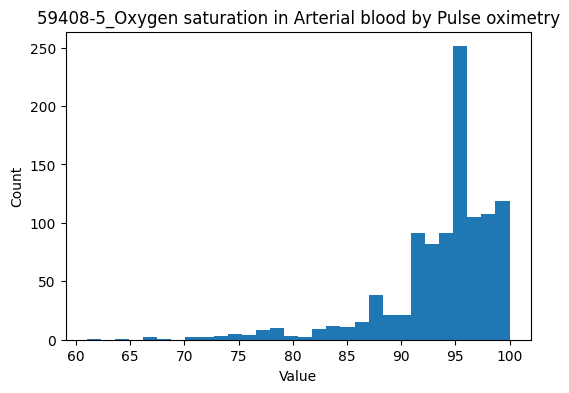

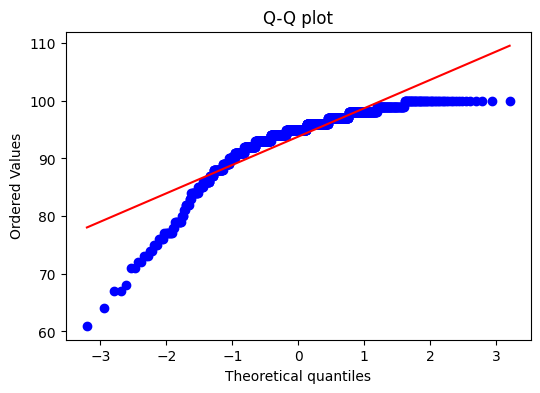


3094-0_Urea nitrogen [Mass/volume] in Serum or Plasma
n: 874
mean: 20.906178489702516
median: 15.0
skewness: 3.5584685787486223


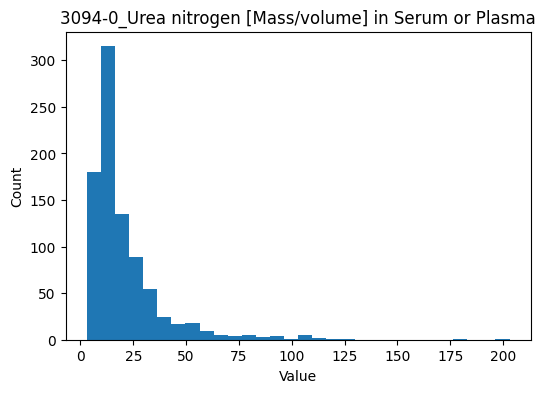

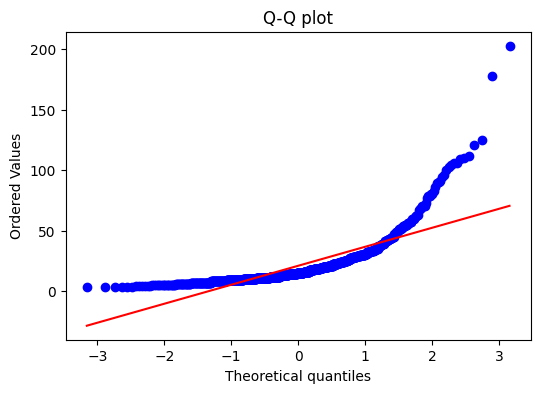


48058-2_Fibrin D-dimer DDU [Mass/volume] in Platelet poor plasma by Immunoassay
n: 711
mean: 1362.676511954993
median: 349.0
skewness: 8.314393288654978


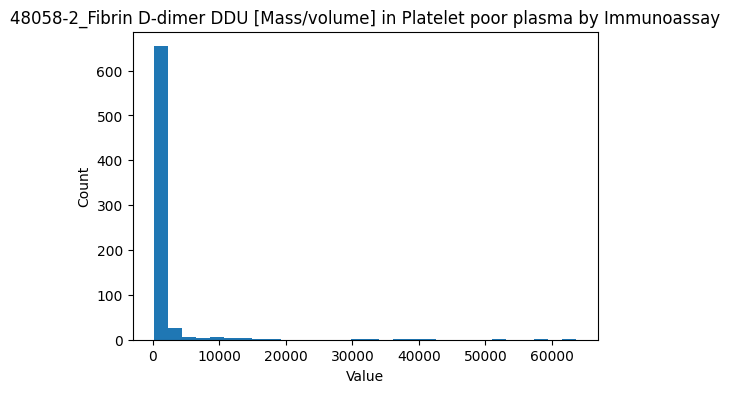

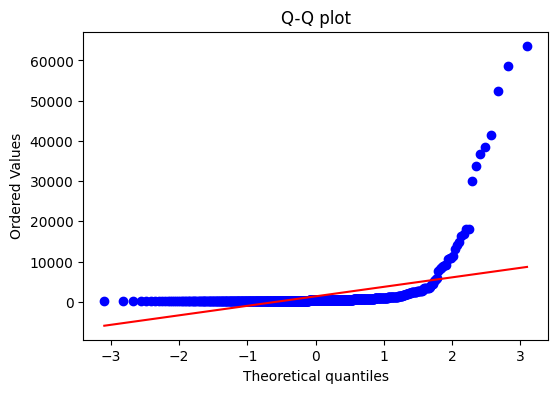

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats

check_vars = [
    "59408-5_Oxygen saturation in Arterial blood by Pulse oximetry",
    "3094-0_Urea nitrogen [Mass/volume] in Serum or Plasma",
    "48058-2_Fibrin D-dimer DDU [Mass/volume] in Platelet poor plasma by Immunoassay"
]

for col in check_vars:
    x = train_df[col].dropna()

    print("\n==============================")
    print(col)
    print("==============================")
    print("n:", len(x))
    print("mean:", x.mean())
    print("median:", x.median())
    print("skewness:", x.skew())

    plt.figure(figsize=(6,4))
    plt.hist(x, bins=30)
    plt.title(col)
    plt.xlabel("Value")
    plt.ylabel("Count")
    plt.show()

    plt.figure(figsize=(6,4))
    stats.probplot(x, dist="norm", plot=plt)
    plt.title("Q-Q plot")
    plt.show()


9279-1_Respiratory rate
n: 1019
mean: 21.919528949950934
median: 20.0
skewness: 3.067606233919941


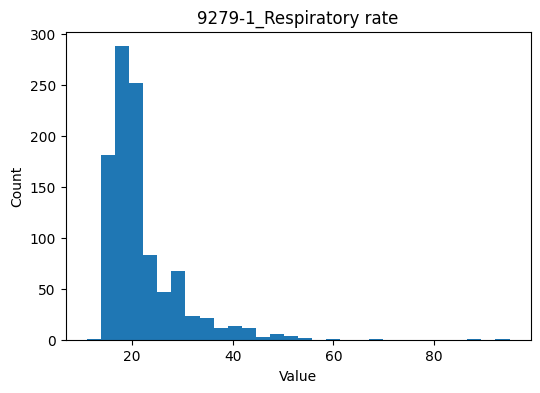

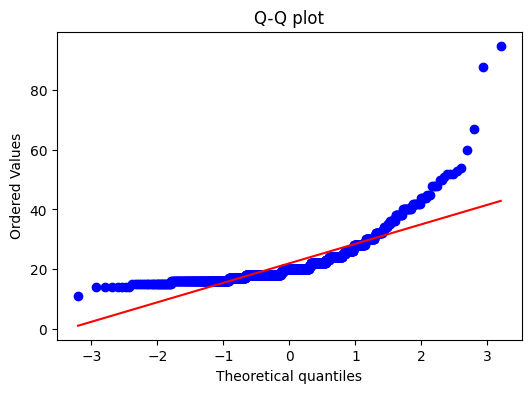


731-0_Lymphocytes [#/volume] in Blood by Automated count
n: 732
mean: 1.0690300546448086
median: 0.94
skewness: 1.8627986273049626


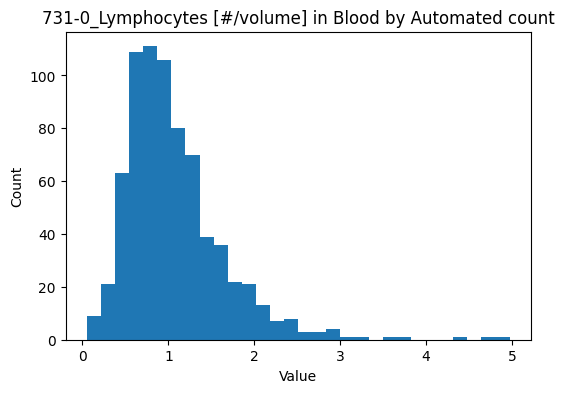

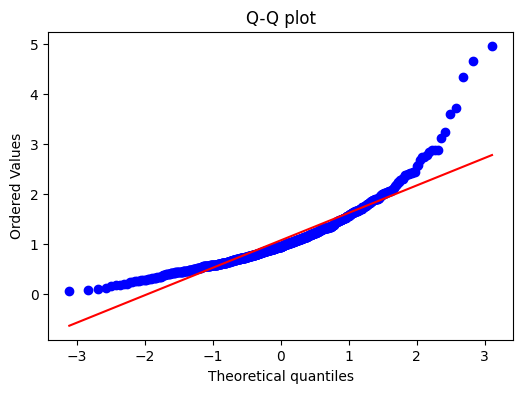


62238-1_Glomerular filtration rate/1.73 sq M.predicted [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (CKD-EPI)
n: 859
mean: 80.87892898719441
median: 86.0
skewness: -0.5619104340446456


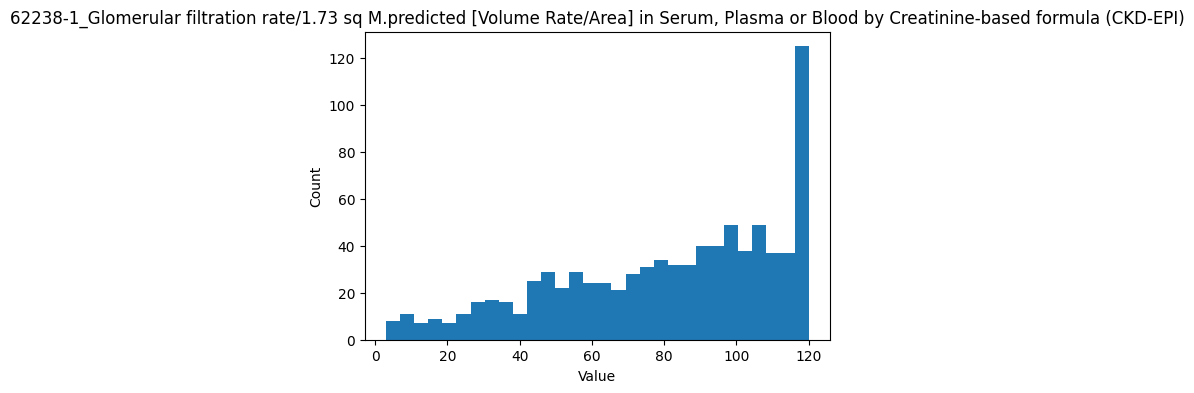

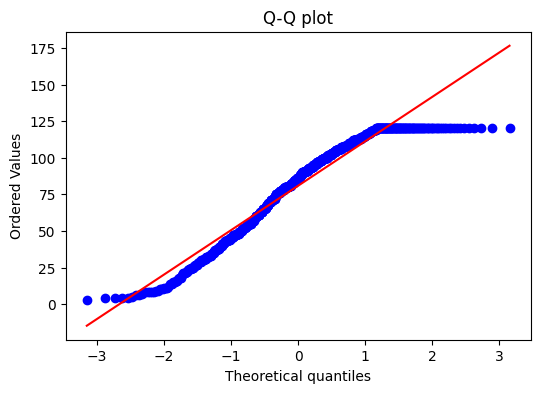


6598-7_Troponin T.cardiac [Mass/volume] in Serum or Plasma
n: 726
mean: 0.029022038567493115
median: 0.01
skewness: 9.51033918319845


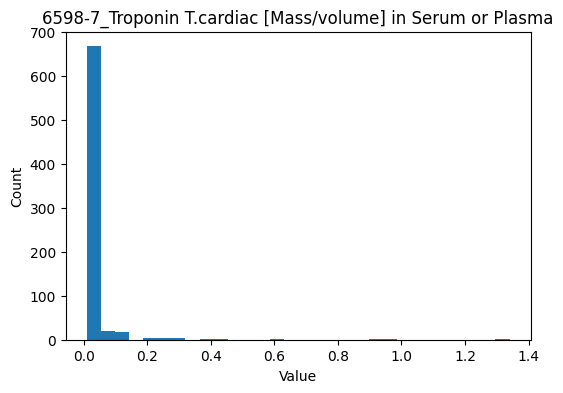

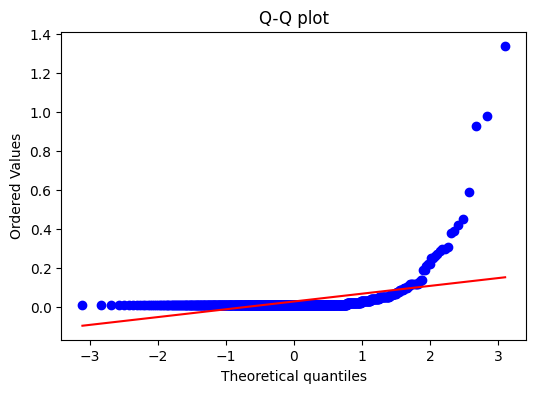


1988-5_C reactive protein [Mass/volume] in Serum or Plasma
n: 793
mean: 10.730264817150063
median: 8.4
skewness: 1.2198338023106985


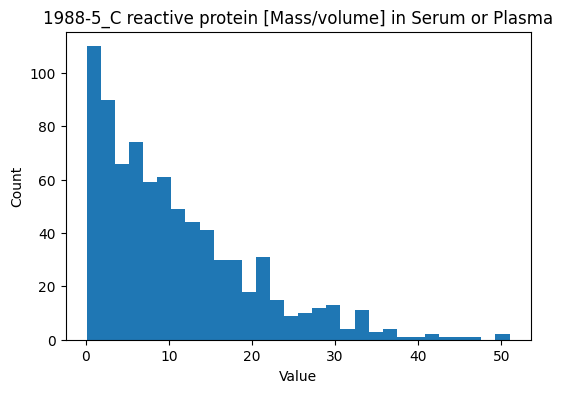

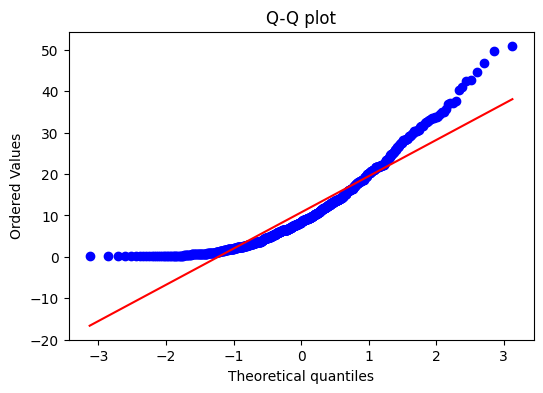


2524-7_Lactate [Moles/volume] in Serum or Plasma
n: 773
mean: 1.8406209573091852
median: 1.5
skewness: 6.549944007985694


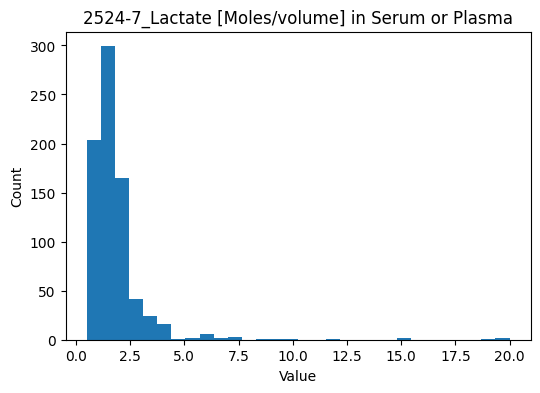

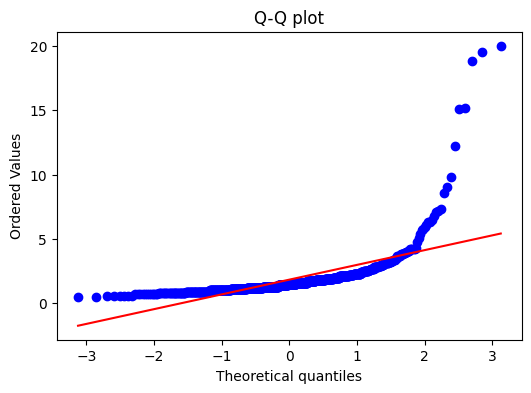

In [ ]:
check_vars_2 = [
    "9279-1_Respiratory rate",
    "731-0_Lymphocytes [#/volume] in Blood by Automated count",
    "62238-1_Glomerular filtration rate/1.73 sq M.predicted [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (CKD-EPI)",
    "6598-7_Troponin T.cardiac [Mass/volume] in Serum or Plasma",
    "1988-5_C reactive protein [Mass/volume] in Serum or Plasma",
    "2524-7_Lactate [Moles/volume] in Serum or Plasma"
]

for col in check_vars_2:
    x = train_df[col].dropna()

    print("\n==============================")
    print(col)
    print("==============================")
    print("n:", len(x))
    print("mean:", x.mean())
    print("median:", x.median())
    print("skewness:", x.skew())

    plt.figure(figsize=(6, 4))
    plt.hist(x, bins=30)
    plt.title(col)
    plt.xlabel("Value")
    plt.ylabel("Count")
    plt.show()

    plt.figure(figsize=(6, 4))
    stats.probplot(x, dist="norm", plot=plt)
    plt.title("Q-Q plot")
    plt.show()

3094-0_Urea nitrogen [Mass/volume] in Serum or Plasma
n: 874
mean: 20.906178489702516
median: 15.0
skewness: 3.5584685787486223


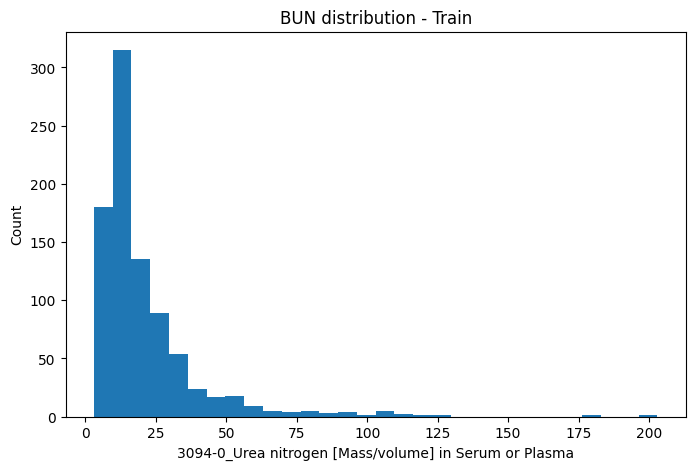

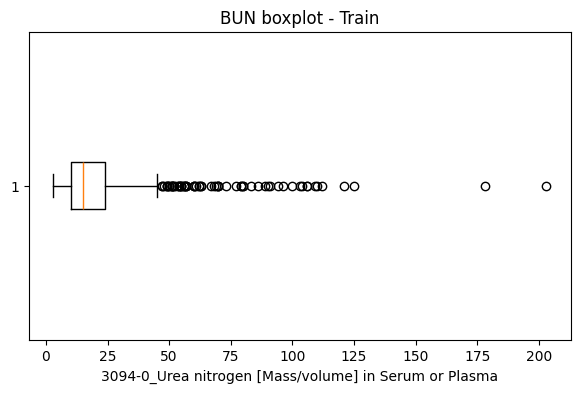

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

var = "3094-0_Urea nitrogen [Mass/volume] in Serum or Plasma"

x = clinical_df.loc[
    clinical_df["split"] == "train",
    var
].dropna()

print("=" * 30)
print(var)
print("=" * 30)
print("n:", len(x))
print("mean:", x.mean())
print("median:", x.median())
print("skewness:", x.skew())

# Histogram
plt.figure(figsize=(8, 5))
plt.hist(x, bins=30)
plt.xlabel(var)
plt.ylabel("Count")
plt.title("BUN distribution - Train")
plt.show()

# Boxplot
plt.figure(figsize=(7, 4))
plt.boxplot(x, vert=False)
plt.xlabel(var)
plt.title("BUN boxplot - Train")
plt.show()


59408-5_Oxygen saturation in Arterial blood by Pulse oximetry
n            : 1018
missing      : 3
missing rate : 0.0029
mean         : 93.7839
median       : 95.0000
skewness     : -2.1002
min / max    : 61.0 / 100.0
Shapiro W    : 0.8086
Shapiro p    : 4.674e-33


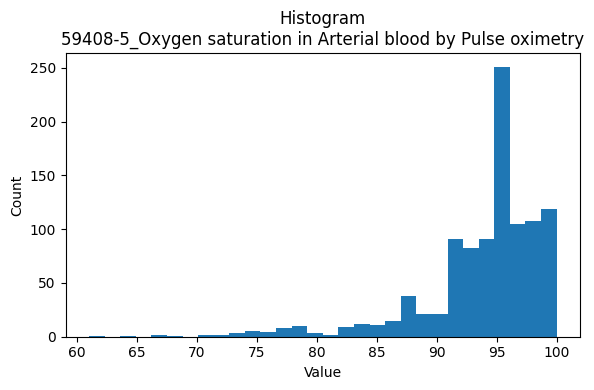

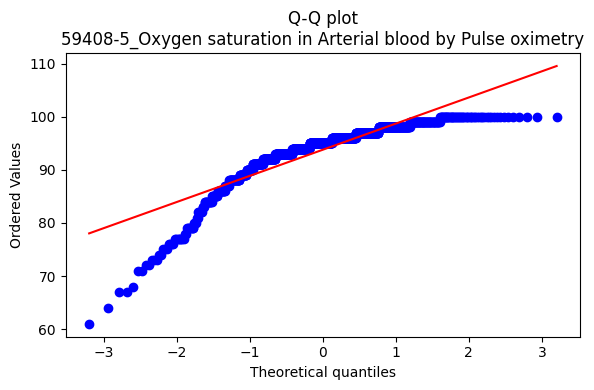


9279-1_Respiratory rate
n            : 1019
missing      : 2
missing rate : 0.0020
mean         : 21.9195
median       : 20.0000
skewness     : 3.0676
min / max    : 11.0 / 95.0
Shapiro W    : 0.7236
Shapiro p    : 5.347e-38


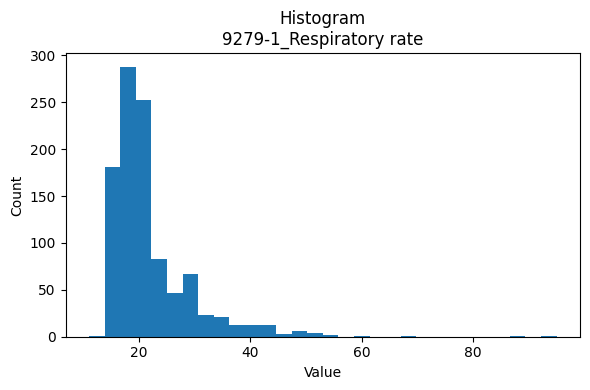

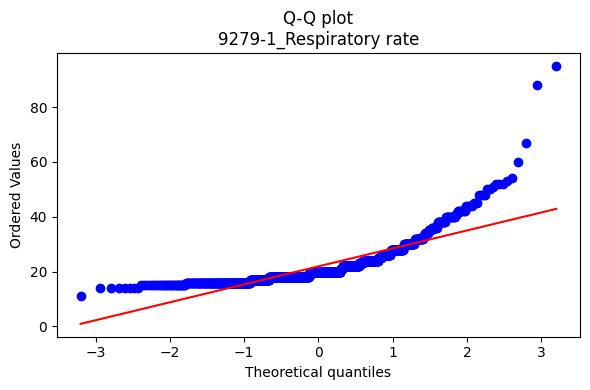


731-0_Lymphocytes [#/volume] in Blood by Automated count
n            : 732
missing      : 289
missing rate : 0.2831
mean         : 1.0690
median       : 0.9400
skewness     : 1.8628
min / max    : 0.05 / 4.97
Shapiro W    : 0.8772
Shapiro p    : 1.428e-23


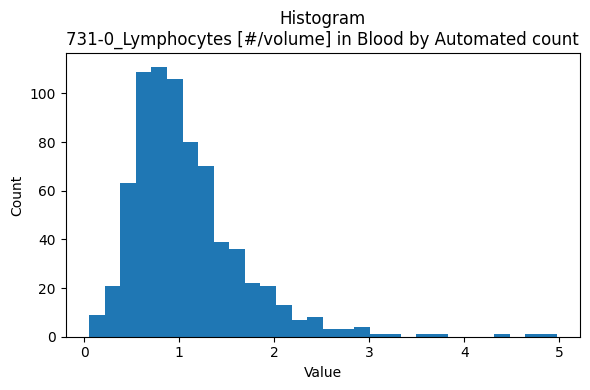

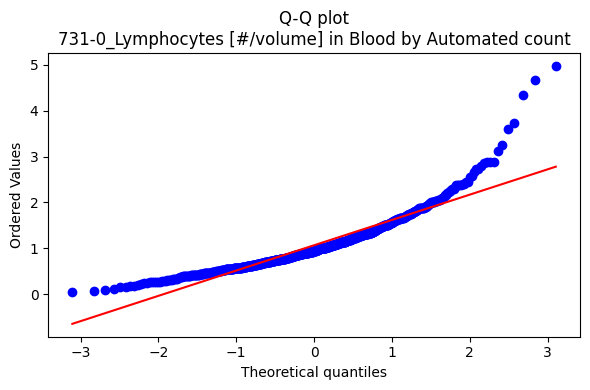


3094-0_Urea nitrogen [Mass/volume] in Serum or Plasma
n            : 874
missing      : 147
missing rate : 0.1440
mean         : 20.9062
median       : 15.0000
skewness     : 3.5585
min / max    : 3.0 / 203.0
Shapiro W    : 0.6619
Shapiro p    : 2.128e-38


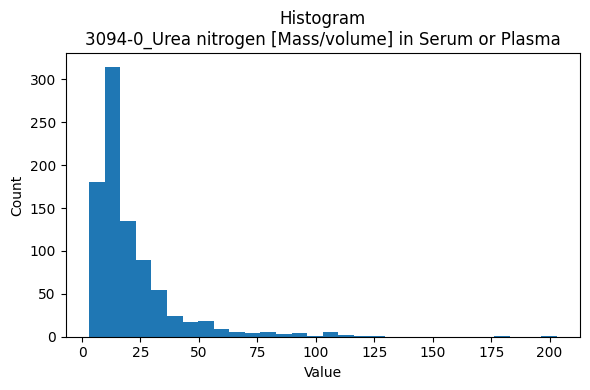

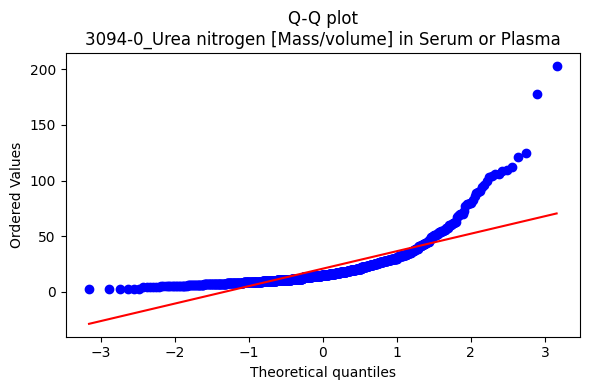


62238-1_Glomerular filtration rate/1.73 sq M.predicted [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (CKD-EPI)
n            : 859
missing      : 162
missing rate : 0.1587
mean         : 80.8789
median       : 86.0000
skewness     : -0.5619
min / max    : 3.0 / 120.0
Shapiro W    : 0.9348
Shapiro p    : 6.601e-19


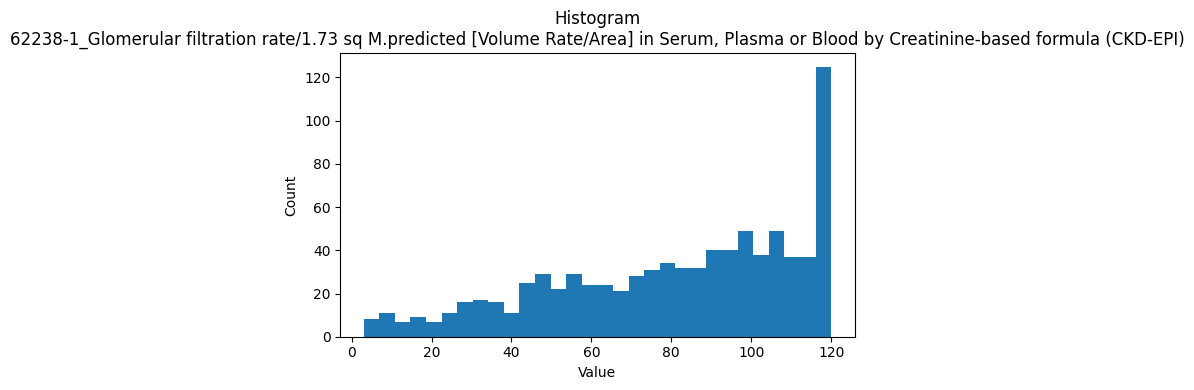

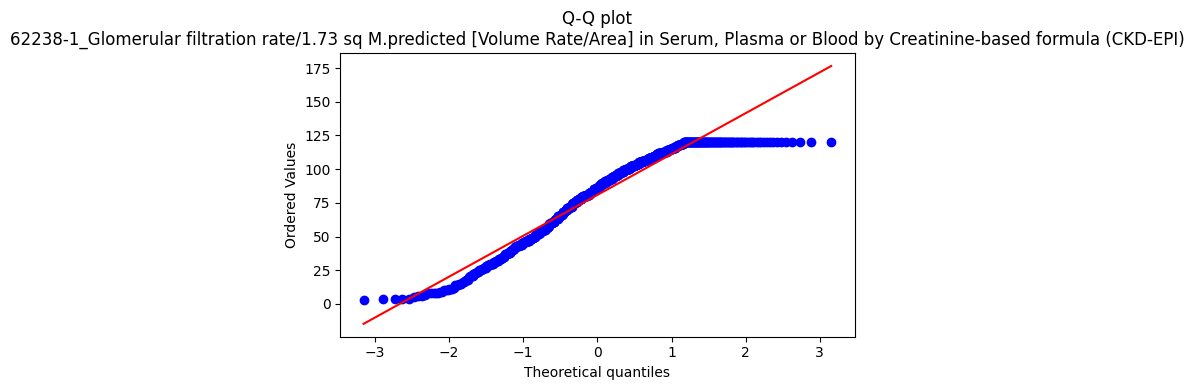


6598-7_Troponin T.cardiac [Mass/volume] in Serum or Plasma
n            : 726
missing      : 295
missing rate : 0.2889
mean         : 0.0290
median       : 0.0100
skewness     : 9.5103
min / max    : 0.01 / 1.34
Shapiro W    : 0.2184
Shapiro p    : 1.466e-47


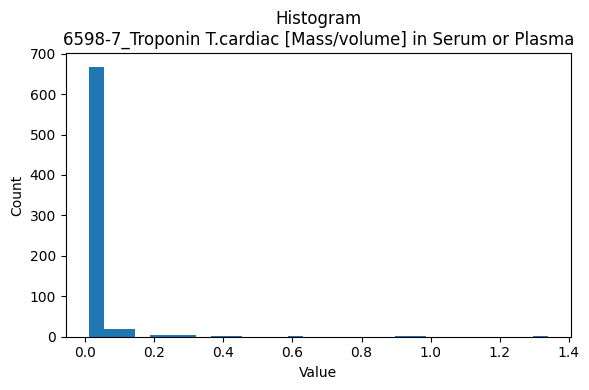

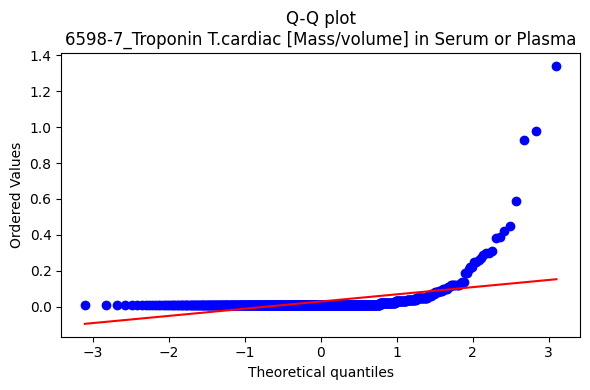


1988-5_C reactive protein [Mass/volume] in Serum or Plasma
n            : 793
missing      : 228
missing rate : 0.2233
mean         : 10.7303
median       : 8.4000
skewness     : 1.2198
min / max    : 0.1 / 51.0
Shapiro W    : 0.8943
Shapiro p    : 6.672e-23


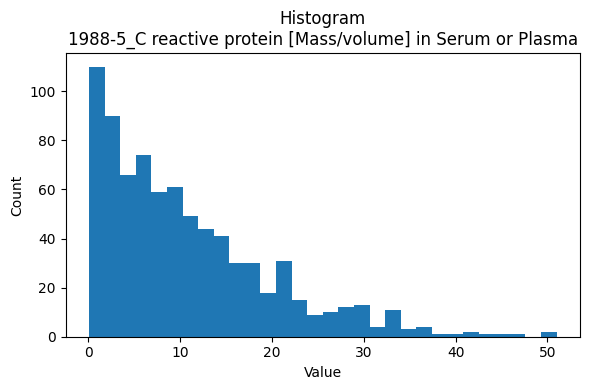

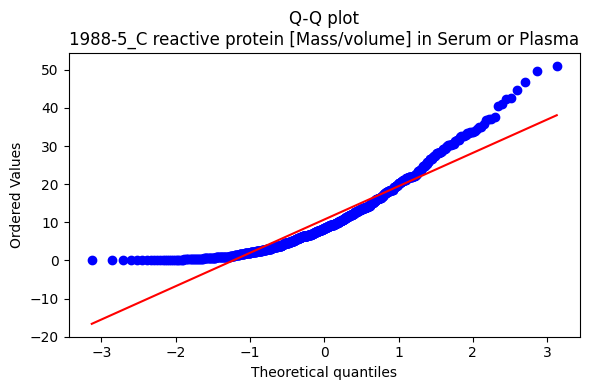


48058-2_Fibrin D-dimer DDU [Mass/volume] in Platelet poor plasma by Immunoassay
n            : 711
missing      : 310
missing rate : 0.3036
mean         : 1362.6765
median       : 349.0000
skewness     : 8.3144
min / max    : 150.0 / 63670.0
Shapiro W    : 0.2114
Shapiro p    : 2.525e-47


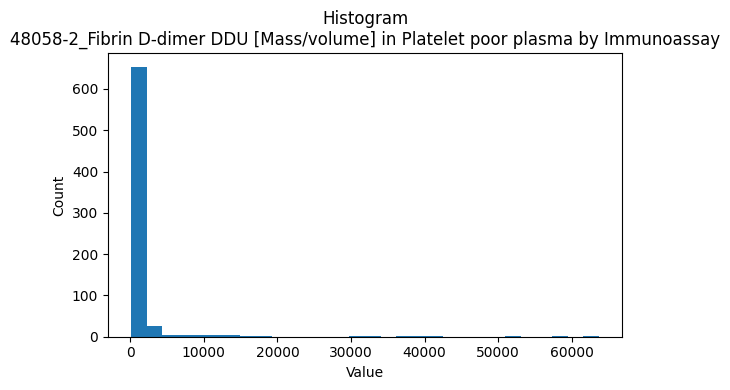

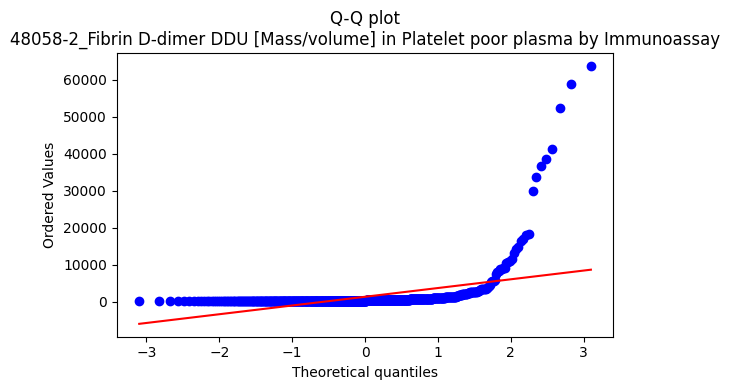


2524-7_Lactate [Moles/volume] in Serum or Plasma
n            : 773
missing      : 248
missing rate : 0.2429
mean         : 1.8406
median       : 1.5000
skewness     : 6.5499
min / max    : 0.5 / 20.0
Shapiro W    : 0.4568
Shapiro p    : 3.549e-43


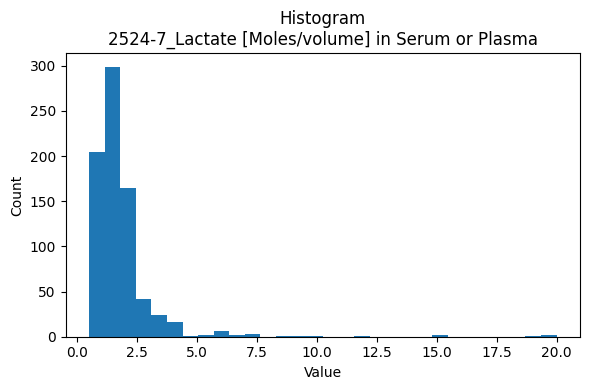

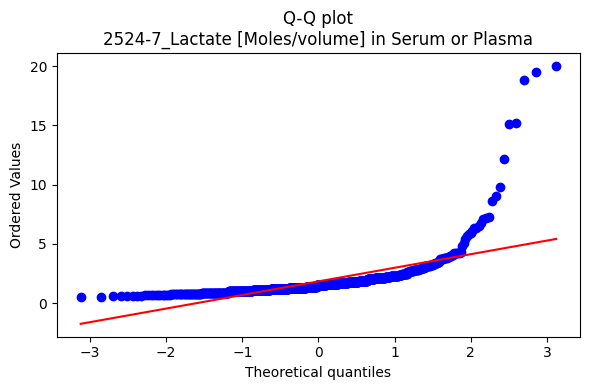

,variable,n,missing_n,missing_rate,mean,sd,median,q1,q3,min,max,skewness,shapiro_W,shapiro_p
0,59408-5_Oxygen saturation in Arterial blood by...,1018,3,0.002938,93.783890,5.459825,95.00,92.00,97.0000,61.00,100.00,-2.100183,0.808582,4.674265e-33
1,9279-1_Respiratory rate,1019,2,0.001959,21.919529,7.692226,20.00,17.00,24.0000,11.00,95.00,3.067606,0.723569,5.346778e-38
2,731-0_Lymphocytes [#/volume] in Blood by Autom...,732,289,0.283056,1.069030,0.586707,0.94,0.68,1.3125,0.05,4.97,1.862799,0.877244,1.427646e-23
3,3094-0_Urea nitrogen [Mass/volume] in Serum or...,874,147,0.143976,20.906178,19.295505,15.00,10.00,24.0000,3.00,203.00,3.558469,0.661874,2.128462e-38
4,62238-1_Glomerular filtration rate/1.73 sq M.p...,859,162,0.158668,80.878929,31.250313,86.00,57.00,107.0000,3.00,120.00,-0.561910,0.934843,6.600676e-19
5,6598-7_Troponin T.cardiac [Mass/volume] in Ser...,726,295,0.288932,0.029022,0.086255,0.01,0.01,0.0100,0.01,1.34,9.510339,0.218384,1.465612e-47
6,1988-5_C reactive protein [Mass/volume] in Ser...,793,228,0.223310,10.730265,9.216148,8.40,3.40,15.4000,0.10,51.00,1.219834,0.894303,6.672480e-23
7,48058-2_Fibrin D-dimer DDU [Mass/volume] in Pl...,711,310,0.303624,1362.676512,5161.521255,349.00,209.00,655.0000,150.00,63670.00,8.314393,0.211434,2.524921e-47
8,2524-7_Lactate [Moles/volume] in Serum or Plasma,773,248,0.242899,1.840621,1.698431,1.50,1.10,2.0000,0.50,20.00,6.549944,0.456776,3.549330e-43


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

continuous_vars = [
    "59408-5_Oxygen saturation in Arterial blood by Pulse oximetry",
    "9279-1_Respiratory rate",
    "731-0_Lymphocytes [#/volume] in Blood by Automated count",
    "3094-0_Urea nitrogen [Mass/volume] in Serum or Plasma",
    "62238-1_Glomerular filtration rate/1.73 sq M.predicted [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (CKD-EPI)",
    "6598-7_Troponin T.cardiac [Mass/volume] in Serum or Plasma",
    "1988-5_C reactive protein [Mass/volume] in Serum or Plasma",
    "48058-2_Fibrin D-dimer DDU [Mass/volume] in Platelet poor plasma by Immunoassay",
    "2524-7_Lactate [Moles/volume] in Serum or Plasma"
]

summary_rows = []

for col in continuous_vars:
    x = pd.to_numeric(train_df[col], errors="coerce").dropna()

    # Shapiro-Wilk
    # scipy の制約を考慮し、5000例超なら固定seedでsample
    if len(x) > 5000:
        shapiro_x = x.sample(5000, random_state=42)
    else:
        shapiro_x = x

    shapiro_stat, shapiro_p = stats.shapiro(shapiro_x)

    summary_rows.append({
        "variable": col,
        "n": len(x),
        "missing_n": train_df[col].isna().sum(),
        "missing_rate": train_df[col].isna().mean(),
        "mean": x.mean(),
        "sd": x.std(),
        "median": x.median(),
        "q1": x.quantile(0.25),
        "q3": x.quantile(0.75),
        "min": x.min(),
        "max": x.max(),
        "skewness": x.skew(),
        "shapiro_W": shapiro_stat,
        "shapiro_p": shapiro_p
    })

    print("\n" + "=" * 80)
    print(col)
    print("=" * 80)
    print(f"n            : {len(x)}")
    print(f"missing      : {train_df[col].isna().sum()}")
    print(f"missing rate : {train_df[col].isna().mean():.4f}")
    print(f"mean         : {x.mean():.4f}")
    print(f"median       : {x.median():.4f}")
    print(f"skewness     : {x.skew():.4f}")
    print(f"min / max    : {x.min()} / {x.max()}")
    print(f"Shapiro W    : {shapiro_stat:.4f}")
    print(f"Shapiro p    : {shapiro_p:.4g}")

    # Histogram
    plt.figure(figsize=(6, 4))
    plt.hist(x, bins=30)
    plt.title(f"Histogram\n{col}")
    plt.xlabel("Value")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # Q-Q plot
    plt.figure(figsize=(6, 4))
    stats.probplot(x, dist="norm", plot=plt)
    plt.title(f"Q-Q plot\n{col}")
    plt.tight_layout()
    plt.show()

distribution_summary = pd.DataFrame(summary_rows)

display(distribution_summary)

In [ ]:
categorical_vars = [
    "age.splits",
    "gender_concept_name",
    "ckd_v",
    "cad_v",
    "hf_ef_v"
]

train_df = clinical_df[clinical_df["split"] == "train"].copy()

for col in categorical_vars:
    print("\n" + "=" * 60)
    print(col)
    print("=" * 60)

    print("missing n:", train_df[col].isna().sum())
    print("missing rate:", train_df[col].isna().mean())

    print("\nvalue counts:")
    print(
        train_df[col]
        .value_counts(dropna=False)
    )


age.splits
missing n: 0
missing rate: 0.0

value counts:
age.splits
[18,59]    544
(59,74]    276
(74,90]    201
Name: count, dtype: int64

gender_concept_name
missing n: 19
missing rate: 0.01860920666013712

value counts:
gender_concept_name
MALE      562
FEMALE    440
NaN        19
Name: count, dtype: int64

ckd_v
missing n: 181
missing rate: 0.1772771792360431

value counts:
ckd_v
No     779
NaN    181
Yes     61
Name: count, dtype: int64

cad_v
missing n: 181
missing rate: 0.1772771792360431

value counts:
cad_v
No     712
NaN    181
Yes    128
Name: count, dtype: int64

hf_ef_v
missing n: 189
missing rate: 0.1851126346718903

value counts:
hf_ef_v
No       775
NaN      189
HFpEF     36
HFrEF     21
Name: count, dtype: int64


In [37]:
import pandas as pd
import numpy as np

# =========================
# 1. 14候補変数
# =========================

continuous_vars = [
    "59408-5_Oxygen saturation in Arterial blood by Pulse oximetry",
    "9279-1_Respiratory rate",
    "731-0_Lymphocytes [#/volume] in Blood by Automated count",
    "3094-0_Urea nitrogen [Mass/volume] in Serum or Plasma",
    "62238-1_Glomerular filtration rate/1.73 sq M.predicted [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (CKD-EPI)",
    "6598-7_Troponin T.cardiac [Mass/volume] in Serum or Plasma",
    "1988-5_C reactive protein [Mass/volume] in Serum or Plasma",
    "48058-2_Fibrin D-dimer DDU [Mass/volume] in Platelet poor plasma by Immunoassay",
    "2524-7_Lactate [Moles/volume] in Serum or Plasma"
]

categorical_vars = [
    "age.splits",
    "gender_concept_name",
    "ckd_v",
    "cad_v",
    "hf_ef_v"
]

candidate_vars = categorical_vars + continuous_vars


# =========================
# 2. Trainだけ抽出
# =========================

train_model_df = clinical_df.loc[
    clinical_df["split"] == "train",
    ["Subject ID", "true_label"] + candidate_vars
].copy()

print("Train shape:", train_model_df.shape)
print("死亡数:", train_model_df["true_label"].sum())
print("生存数:", (train_model_df["true_label"] == 0).sum())


# =========================
# 3. 連続変数
#    Train中央値で補完
# =========================

train_medians = {}

for col in continuous_vars:
    median_value = train_model_df[col].median()
    train_medians[col] = median_value
    train_model_df[col] = train_model_df[col].fillna(median_value)


# =========================
# 4. カテゴリ変数
#    欠損を Missing とする
# =========================

for col in categorical_vars:
    train_model_df[col] = (
        train_model_df[col]
        .astype("object")
        .fillna("Missing")
    )


# =========================
# 5. 最終確認
# =========================

print("\n=== 前処理後の欠損数 ===")
print(train_model_df[candidate_vars].isna().sum())

print("\n=== Train中央値 ===")
for col, value in train_medians.items():
    print(f"{col}: {value}")

print("\n=== カテゴリ分布 ===")
for col in categorical_vars:
    print(f"\n[{col}]")
    print(train_model_df[col].value_counts(dropna=False))

Train shape: (1021, 16)
死亡数: 135
生存数: 886

=== 前処理後の欠損数 ===
age.splits                                                                                                                                   0
gender_concept_name                                                                                                                          0
ckd_v                                                                                                                                        0
cad_v                                                                                                                                        0
hf_ef_v                                                                                                                                      0
59408-5_Oxygen saturation in Arterial blood by Pulse oximetry                                                                                0
9279-1_Respiratory rate                                                           

In [39]:
# statsmodels用に短い列名へ変更
rename_map = {
    "age.splits": "age",
    "gender_concept_name": "sex",
    "ckd_v": "ckd",
    "cad_v": "cad",
    "hf_ef_v": "hf",
    "59408-5_Oxygen saturation in Arterial blood by Pulse oximetry": "spo2",
    "9279-1_Respiratory rate": "rr",
    "731-0_Lymphocytes [#/volume] in Blood by Automated count": "lymph",
    "3094-0_Urea nitrogen [Mass/volume] in Serum or Plasma": "bun",
    "62238-1_Glomerular filtration rate/1.73 sq M.predicted [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (CKD-EPI)": "egfr",
    "6598-7_Troponin T.cardiac [Mass/volume] in Serum or Plasma": "troponin",
    "1988-5_C reactive protein [Mass/volume] in Serum or Plasma": "crp",
    "48058-2_Fibrin D-dimer DDU [Mass/volume] in Platelet poor plasma by Immunoassay": "ddimer",
    "2524-7_Lactate [Moles/volume] in Serum or Plasma": "lactate"
}

train_lr_df = train_model_df.rename(columns=rename_map).copy()

print(train_lr_df.shape)
print(train_lr_df.columns.tolist())

(1021, 16)
['Subject ID', 'true_label', 'age', 'sex', 'ckd', 'cad', 'hf', 'spo2', 'rr', 'lymph', 'bun', 'egfr', 'troponin', 'crp', 'ddimer', 'lactate']


In [40]:
import statsmodels.formula.api as smf
import pandas as pd

# 14元変数
groups = {
    "age": "C(age)",
    "sex": "C(sex)",
    "ckd": "C(ckd)",
    "cad": "C(cad)",
    "hf": "C(hf)",
    "spo2": "spo2",
    "rr": "rr",
    "lymph": "lymph",
    "bun": "bun",
    "egfr": "egfr",
    "troponin": "troponin",
    "crp": "crp",
    "ddimer": "ddimer",
    "lactate": "lactate"
}

selected = list(groups.keys())
history = []

def fit_model(selected_groups):
    rhs = " + ".join(groups[g] for g in selected_groups)
    formula = f"true_label ~ {rhs}"
    model = smf.logit(formula=formula, data=train_lr_df).fit(disp=False)
    return model

# -------------------------
# Full model
# -------------------------
current_model = fit_model(selected)
current_aic = current_model.aic

print("=== Start ===")
print("Variables:", selected)
print("AIC:", current_aic)

# -------------------------
# Backward AIC
# -------------------------
step = 0

while len(selected) > 1:

    candidates = []

    for remove_var in selected:
        trial_vars = [v for v in selected if v != remove_var]

        try:
            trial_model = fit_model(trial_vars)

            candidates.append({
                "remove": remove_var,
                "aic": trial_model.aic,
                "variables_after": trial_vars
            })

        except Exception as e:
            print(f"Failed when removing {remove_var}: {e}")

    candidate_df = pd.DataFrame(candidates).sort_values("aic")

    print(f"\n=== Step {step + 1}: 1変数ずつ外した場合 ===")
    print(candidate_df[["remove", "aic"]].to_string(index=False))

    best = candidate_df.iloc[0]

    # AICが下がる場合だけ削除
    if best["aic"] < current_aic:

        removed = best["remove"]
        new_aic = best["aic"]

        history.append({
            "step": step + 1,
            "removed_variable": removed,
            "aic_before": current_aic,
            "aic_after": new_aic,
            "delta_aic": new_aic - current_aic,
            "n_variables_after": len(best["variables_after"])
        })

        selected = best["variables_after"]
        current_aic = new_aic
        current_model = fit_model(selected)

        print(f"\n→ {removed} を削除")
        print(f"AIC: {history[-1]['aic_before']:.3f} → {new_aic:.3f}")

        step += 1

    else:
        print("\n=== Stop ===")
        print("どの変数を外してもAICが改善しないため終了")
        break


# -------------------------
# 最終結果
# -------------------------
history_df = pd.DataFrame(history)

print("\n==============================")
print("最終選択変数")
print("==============================")
print(selected)

print("\n最終変数数:", len(selected))
print("最終AIC:", current_model.aic)

print("\n==============================")
print("削除履歴")
print("==============================")
print(history_df)

print("\n==============================")
print("最終モデル")
print("==============================")
print(current_model.summary())

=== Start ===
Variables: ['age', 'sex', 'ckd', 'cad', 'hf', 'spo2', 'rr', 'lymph', 'bun', 'egfr', 'troponin', 'crp', 'ddimer', 'lactate']
AIC: 438.12585306971357

=== Step 1: 1変数ずつ外した場合 ===
  remove        aic
     cad 436.038778
troponin 436.349697
     bun 436.404635
  ddimer 436.450666
      rr 437.004392
     ckd 438.596251
    egfr 440.250284
     crp 449.504027
      hf 449.584590
   lymph 449.616898
    spo2 452.267688
 lactate 452.436934
     age 521.626993
     sex 538.706981

→ cad を削除
AIC: 438.126 → 436.039

=== Step 2: 1変数ずつ外した場合 ===
  remove        aic
troponin 434.249801
     bun 434.273700
  ddimer 434.412538
      rr 434.898205
     ckd 436.009617
    egfr 438.467490
     crp 447.117017
      hf 447.376098
   lymph 447.376934
 lactate 450.110513
    spo2 450.168295
     age 525.862411
     sex 537.024217

→ troponin を削除
AIC: 436.039 → 434.250

=== Step 3: 1変数ずつ外した場合 ===
 remove        aic
    bun 432.442111
 ddimer 432.595361
     rr 433.241317
    ckd 434.222078
   egf

In [41]:
pd.crosstab(
    train_lr_df["sex"],
    train_lr_df["true_label"],
    margins=True
)

true_label,0,1,All
sex,,,
FEMALE,399,41,440
MALE,486,76,562
Missing,1,18,19
All,886,135,1021


In [42]:
# 性別欠損をTrain最頻値で補完
train_model_df["gender_concept_name"] = (
    train_model_df["gender_concept_name"]
    .replace("Missing", np.nan)
)

gender_mode = train_model_df["gender_concept_name"].mode(dropna=True)[0]

train_model_df["gender_concept_name"] = (
    train_model_df["gender_concept_name"]
    .fillna(gender_mode)
)

print("Train gender mode:", gender_mode)
print("\n=== 補完後の性別分布 ===")
print(train_model_df["gender_concept_name"].value_counts(dropna=False))

Train gender mode: MALE

=== 補完後の性別分布 ===
gender_concept_name
MALE      581
FEMALE    440
Name: count, dtype: int64


In [43]:
# statsmodels用データを作り直す
train_lr_df = train_model_df.rename(columns=rename_map).copy()

print(train_lr_df.shape)

print("\n=== 性別分布 ===")
print(train_lr_df["sex"].value_counts(dropna=False))

print("\n=== 性別 × outcome ===")
print(pd.crosstab(
    train_lr_df["sex"],
    train_lr_df["true_label"],
    margins=True
))

(1021, 16)

=== 性別分布 ===
sex
MALE      581
FEMALE    440
Name: count, dtype: int64

=== 性別 × outcome ===
true_label    0    1   All
sex                       
FEMALE      399   41   440
MALE        487   94   581
All         886  135  1021


In [44]:
import statsmodels.formula.api as smf
import pandas as pd

# 14元変数
groups = {
    "age": "C(age)",
    "sex": "C(sex)",
    "ckd": "C(ckd)",
    "cad": "C(cad)",
    "hf": "C(hf)",
    "spo2": "spo2",
    "rr": "rr",
    "lymph": "lymph",
    "bun": "bun",
    "egfr": "egfr",
    "troponin": "troponin",
    "crp": "crp",
    "ddimer": "ddimer",
    "lactate": "lactate"
}

selected = list(groups.keys())
history = []

def fit_model(selected_groups):
    rhs = " + ".join(groups[g] for g in selected_groups)
    formula = f"true_label ~ {rhs}"
    model = smf.logit(formula=formula, data=train_lr_df).fit(disp=False)
    return model

# -------------------------
# Full model
# -------------------------
current_model = fit_model(selected)
current_aic = current_model.aic

print("=== Start ===")
print("Variables:", selected)
print("AIC:", current_aic)

# -------------------------
# Backward AIC
# -------------------------
step = 0

while len(selected) > 1:

    candidates = []

    for remove_var in selected:
        trial_vars = [v for v in selected if v != remove_var]

        try:
            trial_model = fit_model(trial_vars)

            candidates.append({
                "remove": remove_var,
                "aic": trial_model.aic,
                "variables_after": trial_vars
            })

        except Exception as e:
            print(f"Failed when removing {remove_var}: {e}")

    candidate_df = pd.DataFrame(candidates).sort_values("aic")

    print(f"\n=== Step {step + 1}: 1変数ずつ外した場合 ===")
    print(candidate_df[["remove", "aic"]].to_string(index=False))

    best = candidate_df.iloc[0]

    # AICが下がる場合だけ削除
    if best["aic"] < current_aic:

        removed = best["remove"]
        new_aic = best["aic"]

        history.append({
            "step": step + 1,
            "removed_variable": removed,
            "aic_before": current_aic,
            "aic_after": new_aic,
            "delta_aic": new_aic - current_aic,
            "n_variables_after": len(best["variables_after"])
        })

        selected = best["variables_after"]
        current_aic = new_aic
        current_model = fit_model(selected)

        print(f"\n→ {removed} を削除")
        print(f"AIC: {history[-1]['aic_before']:.3f} → {new_aic:.3f}")

        step += 1

    else:
        print("\n=== Stop ===")
        print("どの変数を外してもAICが改善しないため終了")
        break


# -------------------------
# 最終結果
# -------------------------
history_df = pd.DataFrame(history)

print("\n==============================")
print("最終選択変数")
print("==============================")
print(selected)

print("\n最終変数数:", len(selected))
print("最終AIC:", current_model.aic)

print("\n==============================")
print("削除履歴")
print("==============================")
print(history_df)

print("\n==============================")
print("最終モデル")
print("==============================")
print(current_model.summary())

=== Start ===
Variables: ['age', 'sex', 'ckd', 'cad', 'hf', 'spo2', 'rr', 'lymph', 'bun', 'egfr', 'troponin', 'crp', 'ddimer', 'lactate']
AIC: 533.0742590136354

=== Step 1: 1変数ずつ外した場合 ===
  remove        aic
     cad 530.785970
  ddimer 531.077513
troponin 531.124839
     bun 531.654317
     ckd 533.288639
      rr 534.184410
    egfr 537.008156
     sex 538.706981
   lymph 544.250179
 lactate 544.451159
      hf 544.634816
    spo2 550.319719
     crp 550.921890
     age 573.610045

→ cad を削除
AIC: 533.074 → 530.786

=== Step 2: 1変数ずつ外した場合 ===
  remove        aic
  ddimer 528.795296
troponin 528.829791
     bun 529.356242
     ckd 530.555854
      rr 531.867699
    egfr 535.205548
     sex 537.024217
   lymph 541.755867
 lactate 541.966845
      hf 542.475157
    spo2 547.987572
     crp 548.530493
     age 576.239505

→ ddimer を削除
AIC: 530.786 → 528.795

=== Step 3: 1変数ずつ外した場合 ===
  remove        aic
troponin 526.837318
     bun 527.371090
     ckd 528.577042
      rr 529.872417
    

In [45]:
import os
import json
import pandas as pd

# =========================
# 保存先
# =========================
SAVE_DIR = os.path.join(
    BASE_DIR,
    "02_TaskB_臨床データ",
    "01_変数選定"
)
os.makedirs(SAVE_DIR, exist_ok=True)


# =========================
# 1. Backward AIC 削除履歴
# =========================
history_path = os.path.join(
    SAVE_DIR,
    "TaskB_BackwardAIC_変数選択履歴.csv"
)

history_df.to_csv(
    history_path,
    index=False,
    encoding="utf-8-sig"
)


# =========================
# 2. 最終選択変数
# =========================
selected_df = pd.DataFrame({
    "variable": selected,
    "selected": True
})

selected_path = os.path.join(
    SAVE_DIR,
    "TaskB_BackwardAIC_最終選択変数.csv"
)

selected_df.to_csv(
    selected_path,
    index=False,
    encoding="utf-8-sig"
)


# =========================
# 3. 最終モデル係数
# =========================
coef_df = pd.DataFrame({
    "term": current_model.params.index,
    "coef": current_model.params.values,
    "std_error": current_model.bse.values,
    "p_value": current_model.pvalues.values,
    "ci_lower_95": current_model.conf_int()[0].values,
    "ci_upper_95": current_model.conf_int()[1].values
})

coef_path = os.path.join(
    SAVE_DIR,
    "TaskB_BackwardAIC_最終モデル係数.csv"
)

coef_df.to_csv(
    coef_path,
    index=False,
    encoding="utf-8-sig"
)


# =========================
# 4. statsmodels summary
# =========================
summary_path = os.path.join(
    SAVE_DIR,
    "TaskB_BackwardAIC_最終モデルsummary.txt"
)

with open(summary_path, "w", encoding="utf-8") as f:
    f.write(current_model.summary().as_text())


# =========================
# 5. 解析条件・最終結果
# =========================
full_model_for_save = fit_model(list(groups.keys()))

metadata = {
    "analysis": "Backward elimination using AIC",
    "dataset": "Train only",
    "train_n": int(len(train_lr_df)),
    "train_deaths": int(train_lr_df["true_label"].sum()),
    "initial_raw_variables": 14,
    "initial_aic": float(full_model_for_save.aic),
    "final_raw_variables": int(len(selected)),
    "final_selected_variables": selected,
    "final_aic": float(current_model.aic),
    "gender_missing_handling": "Imputed with Train mode (MALE); Missing category not used",
    "continuous_missing_handling": "Train median imputation",
    "categorical_selection_unit": "Original clinical variable as a group",
    "selection_criterion": "Remove variable only when AIC decreases",
    "test_used": False
}

metadata_path = os.path.join(
    SAVE_DIR,
    "TaskB_BackwardAIC_解析条件・結果.json"
)

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)


# =========================
# 保存確認
# =========================
print("=== 保存完了 ===")
for p in [
    history_path,
    selected_path,
    coef_path,
    summary_path,
    metadata_path
]:
    print(p)

=== 保存完了 ===
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/01_変数選定/TaskB_BackwardAIC_変数選択履歴.csv
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/01_変数選定/TaskB_BackwardAIC_最終選択変数.csv
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/01_変数選定/TaskB_BackwardAIC_最終モデル係数.csv
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/01_変数選定/TaskB_BackwardAIC_最終モデルsummary.txt
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/01_変数選定/TaskB_BackwardAIC_解析条件・結果.json
